# Evaluate Branch Lengths

In [1]:
from Bio import Nexus, Phylo, SeqIO
from collections import defaultdict
from io import StringIO

import matplotlib.pyplot as plt
from matplotlib import gridspec

import seaborn as sns

import pandas as pd
import numpy as np

import re
from pathlib import Path

from itertools import combinations

from evaluation_helpers import *

In [2]:
input_csv = "../scripts/successful_mcmc_runs.csv" 
overview_df, df_failed = process_results(input_csv)
overview_df.head()

#overview_df_ = add_tree_information(overview_df_)
overview_df_ = pd.read_pickle("../results/run1/evaluation/df_pop_info.pkl")
overview_df_.head()

tree_metrics_combined = pd.read_csv("../results/run1/evaluation/tree_metrics_combined.csv")

/var/folders/l3/cr7pvqjn2054djbp5cf7qbd40000gn/T/ipykernel_36501/1669375747.py:9: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  tree_metrics_combined = pd.read_csv("../results/run1/evaluation/tree_metrics_combined.csv")


## Are estimated confidence intervals matching true simulated branch lengths

In [4]:
tree_metrics_combined_linearconstant = tree_metrics_combined[tree_metrics_combined["sampling"] == "linearconstant"].copy()
tree_metrics_combined_independenthomochronous = tree_metrics_combined[tree_metrics_combined["sampling"] == "independenthomochronous"].copy()

# bl makes sense for all nodes besides the root

display(tree_metrics_combined[(tree_metrics_combined["model"] == "skyline") & (tree_metrics_combined["node"] != "internal_0")].bl_inside_ci.value_counts())
display(tree_metrics_combined[(tree_metrics_combined["model"] == "constcoal") & (tree_metrics_combined["node"] != "internal_0")].bl_inside_ci.value_counts())

display(tree_metrics_combined_linearconstant[(tree_metrics_combined_linearconstant["model"] == "skyline") & (tree_metrics_combined_linearconstant["node"] != "internal_0")].bl_inside_ci.value_counts())
display(tree_metrics_combined_linearconstant[(tree_metrics_combined_linearconstant["model"] == "constcoal") & (tree_metrics_combined_linearconstant["node"] != "internal_0")].bl_inside_ci.value_counts())

display(tree_metrics_combined_independenthomochronous[(tree_metrics_combined_independenthomochronous["model"] == "skyline") & (tree_metrics_combined_independenthomochronous["node"] != "internal_0")].bl_inside_ci.value_counts())
display(tree_metrics_combined_independenthomochronous[(tree_metrics_combined_independenthomochronous["model"] == "constcoal") & (tree_metrics_combined_independenthomochronous["node"] != "internal_0")].bl_inside_ci.value_counts())

bl_inside_ci
True     810616
False    135306
Name: count, dtype: int64

bl_inside_ci
True     836482
False    109440
Name: count, dtype: int64

bl_inside_ci
True     457367
False    112565
Name: count, dtype: int64

bl_inside_ci
True     483527
False     86405
Name: count, dtype: int64

bl_inside_ci
True     353249
False     22741
Name: count, dtype: int64

bl_inside_ci
True     352955
False     23035
Name: count, dtype: int64

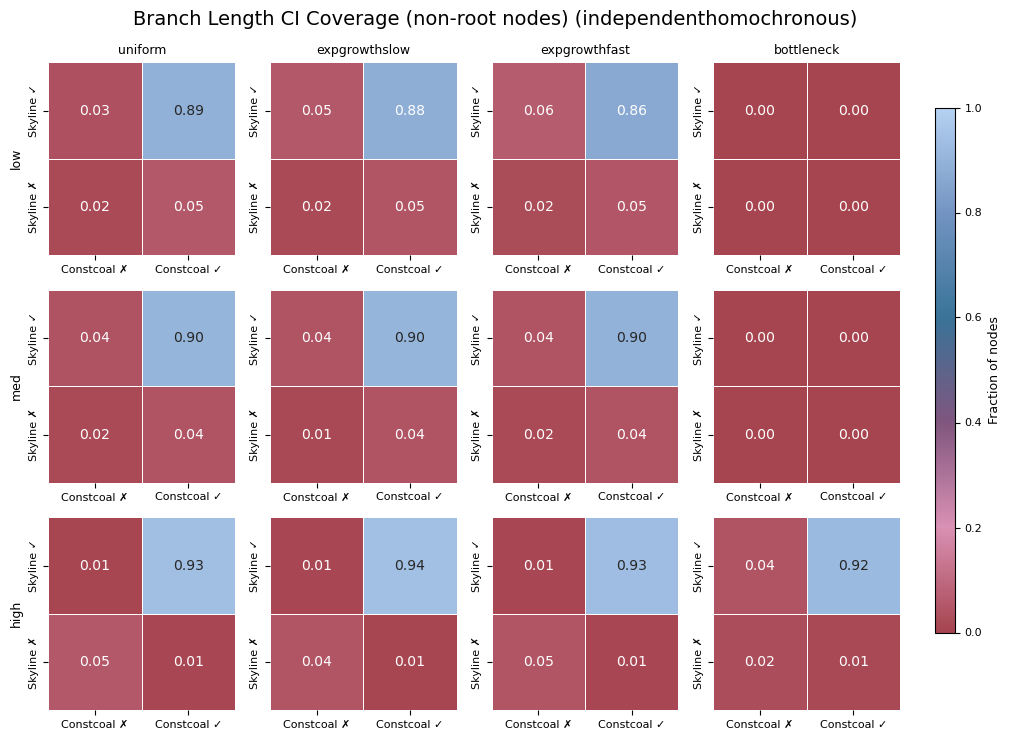

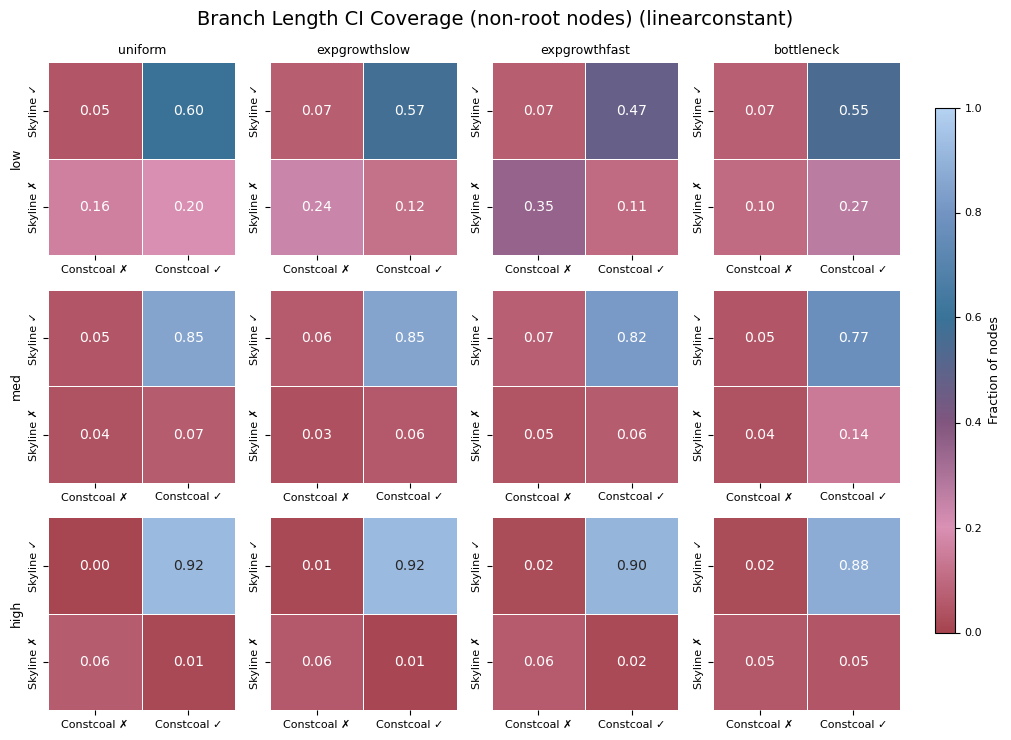

In [3]:
plot_ci_coverage_heatmap_nodes(tree_metrics_combined, mode="bl")

## Overall branch length box plot

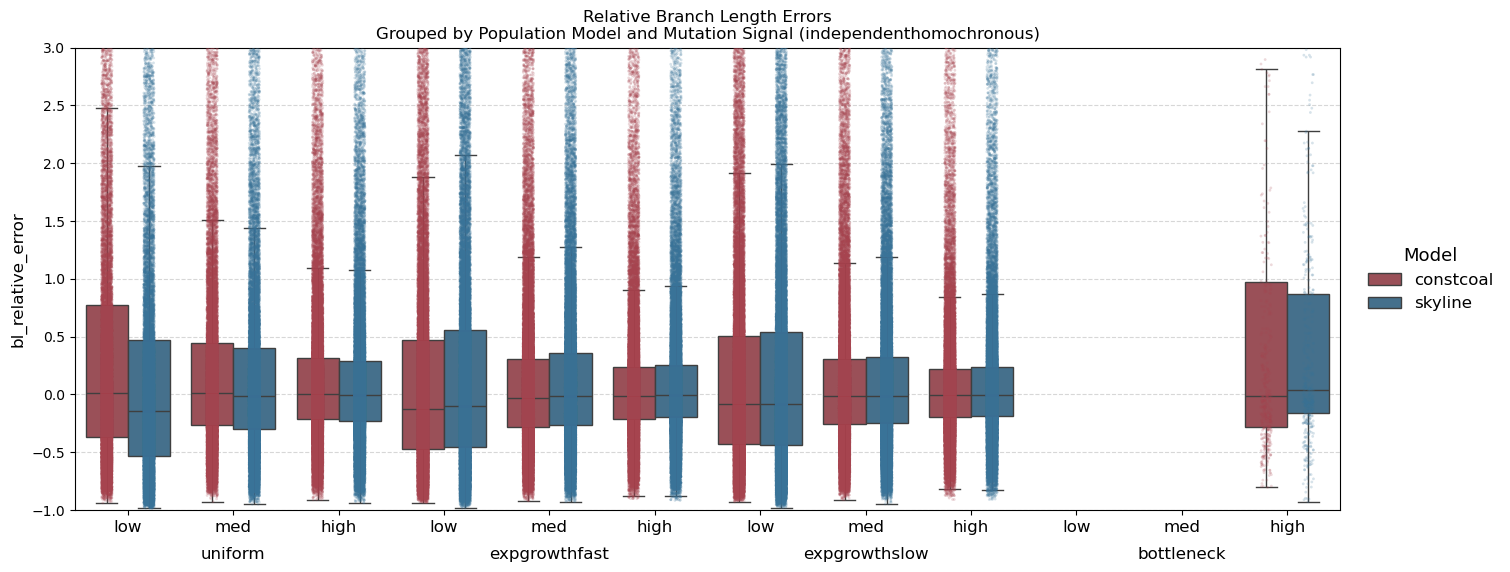

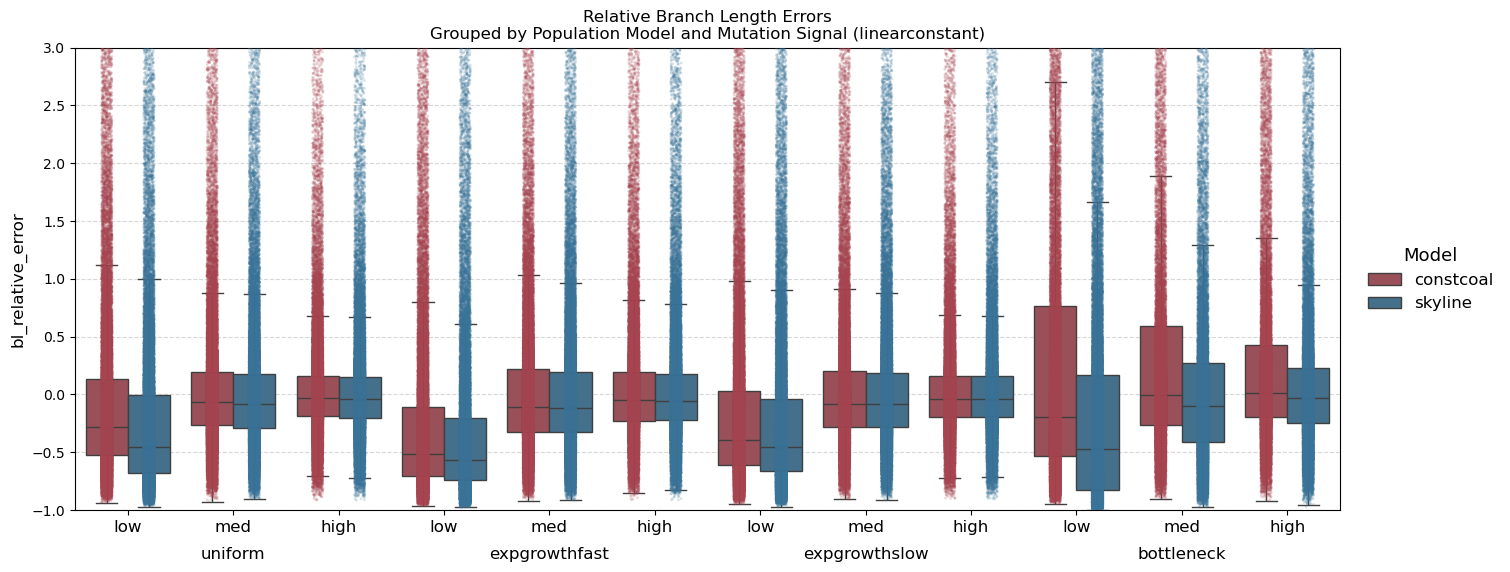

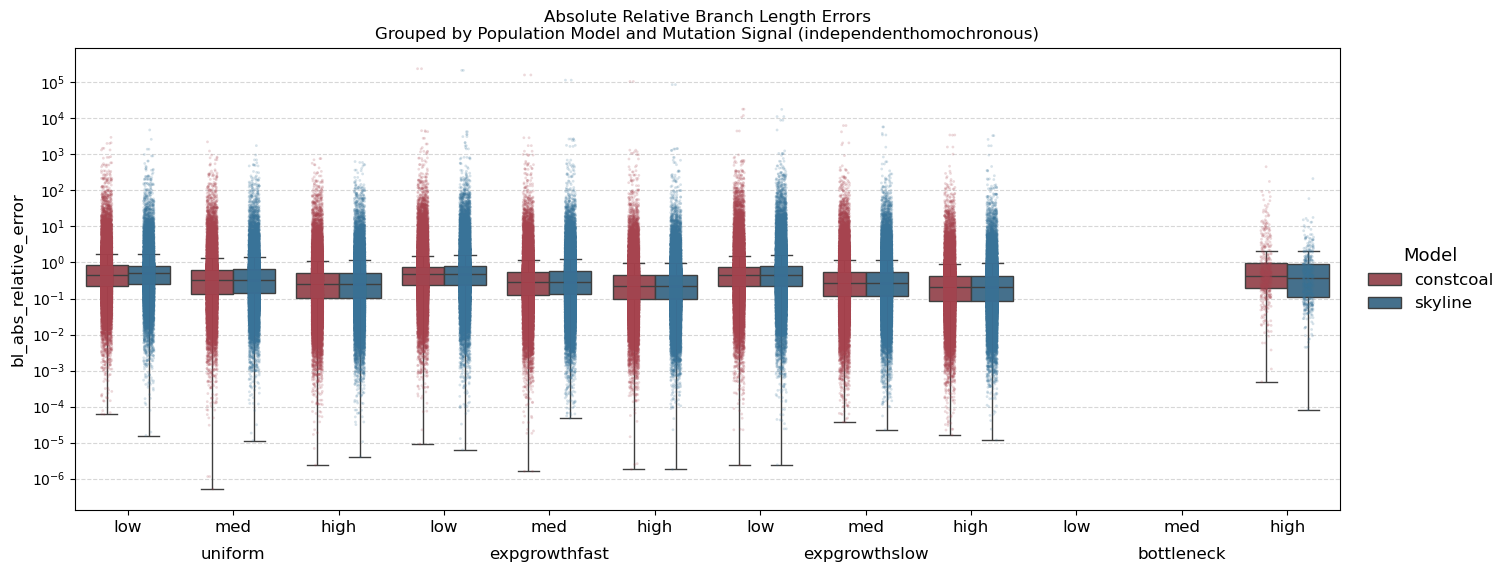

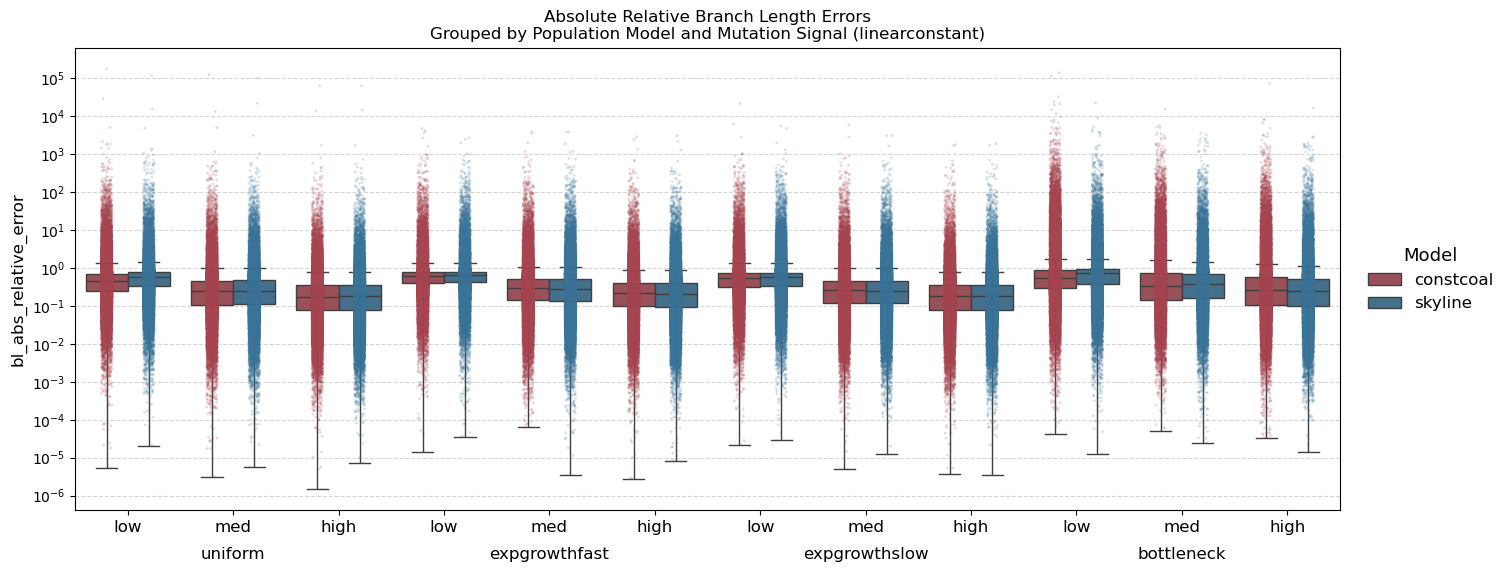

In [6]:
# branch lengths
# errors cancel each other out if we look at absolute errors because skyline sometimes has a little bit negative errors because it sometimes underestimates pop-size

boxplot_branch_length_errors(tree_metrics_combined[tree_metrics_combined["node"] != "internal_0"], sampling = "independenthomochronous", metric="bl_relative_error", title="Relative Branch Length Errors\nGrouped by Population Model and Mutation Signal", logscale = False, y_range= (-1,3), plot_type = "box")
boxplot_branch_length_errors(tree_metrics_combined[tree_metrics_combined["node"] != "internal_0"], sampling = "linearconstant", metric="bl_relative_error", title="Relative Branch Length Errors\nGrouped by Population Model and Mutation Signal", logscale = False, y_range= (-1,3), plot_type = "box")

# branch lengths absolute errors --> show even less
boxplot_branch_length_errors(tree_metrics_combined[tree_metrics_combined["node"] != "internal_0"], sampling = "independenthomochronous", metric="bl_abs_relative_error", title="Absolute Relative Branch Length Errors\nGrouped by Population Model and Mutation Signal", logscale = True, plot_type = "box")
boxplot_branch_length_errors(tree_metrics_combined[tree_metrics_combined["node"] != "internal_0"], sampling = "linearconstant", metric="bl_abs_relative_error", title="Absolute Relative Branch Length Errors\nGrouped by Population Model and Mutation Signal", logscale = True, plot_type = "box")

## Error development over time

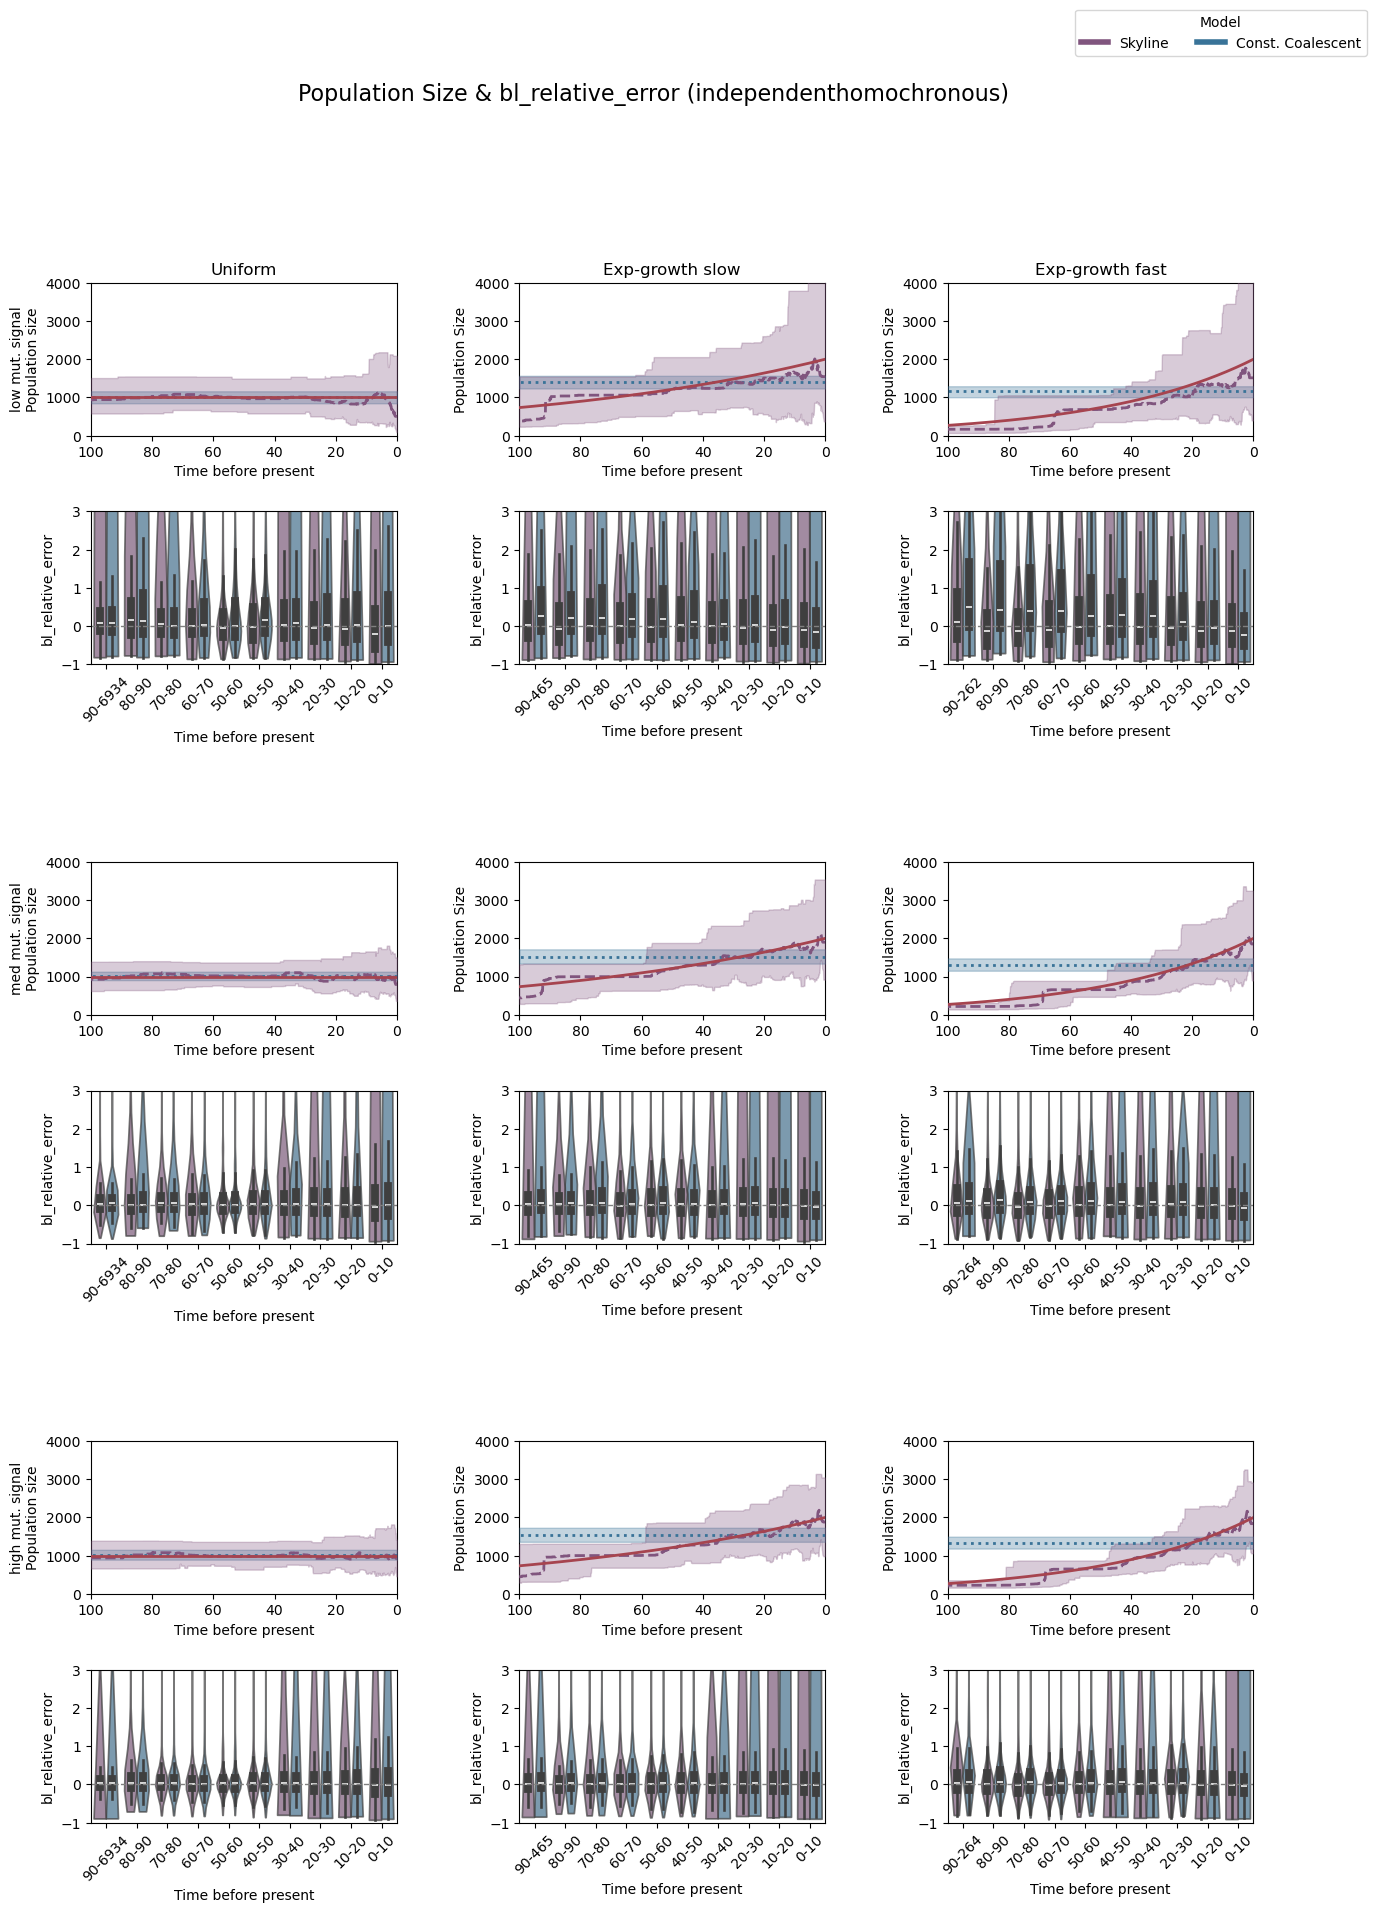

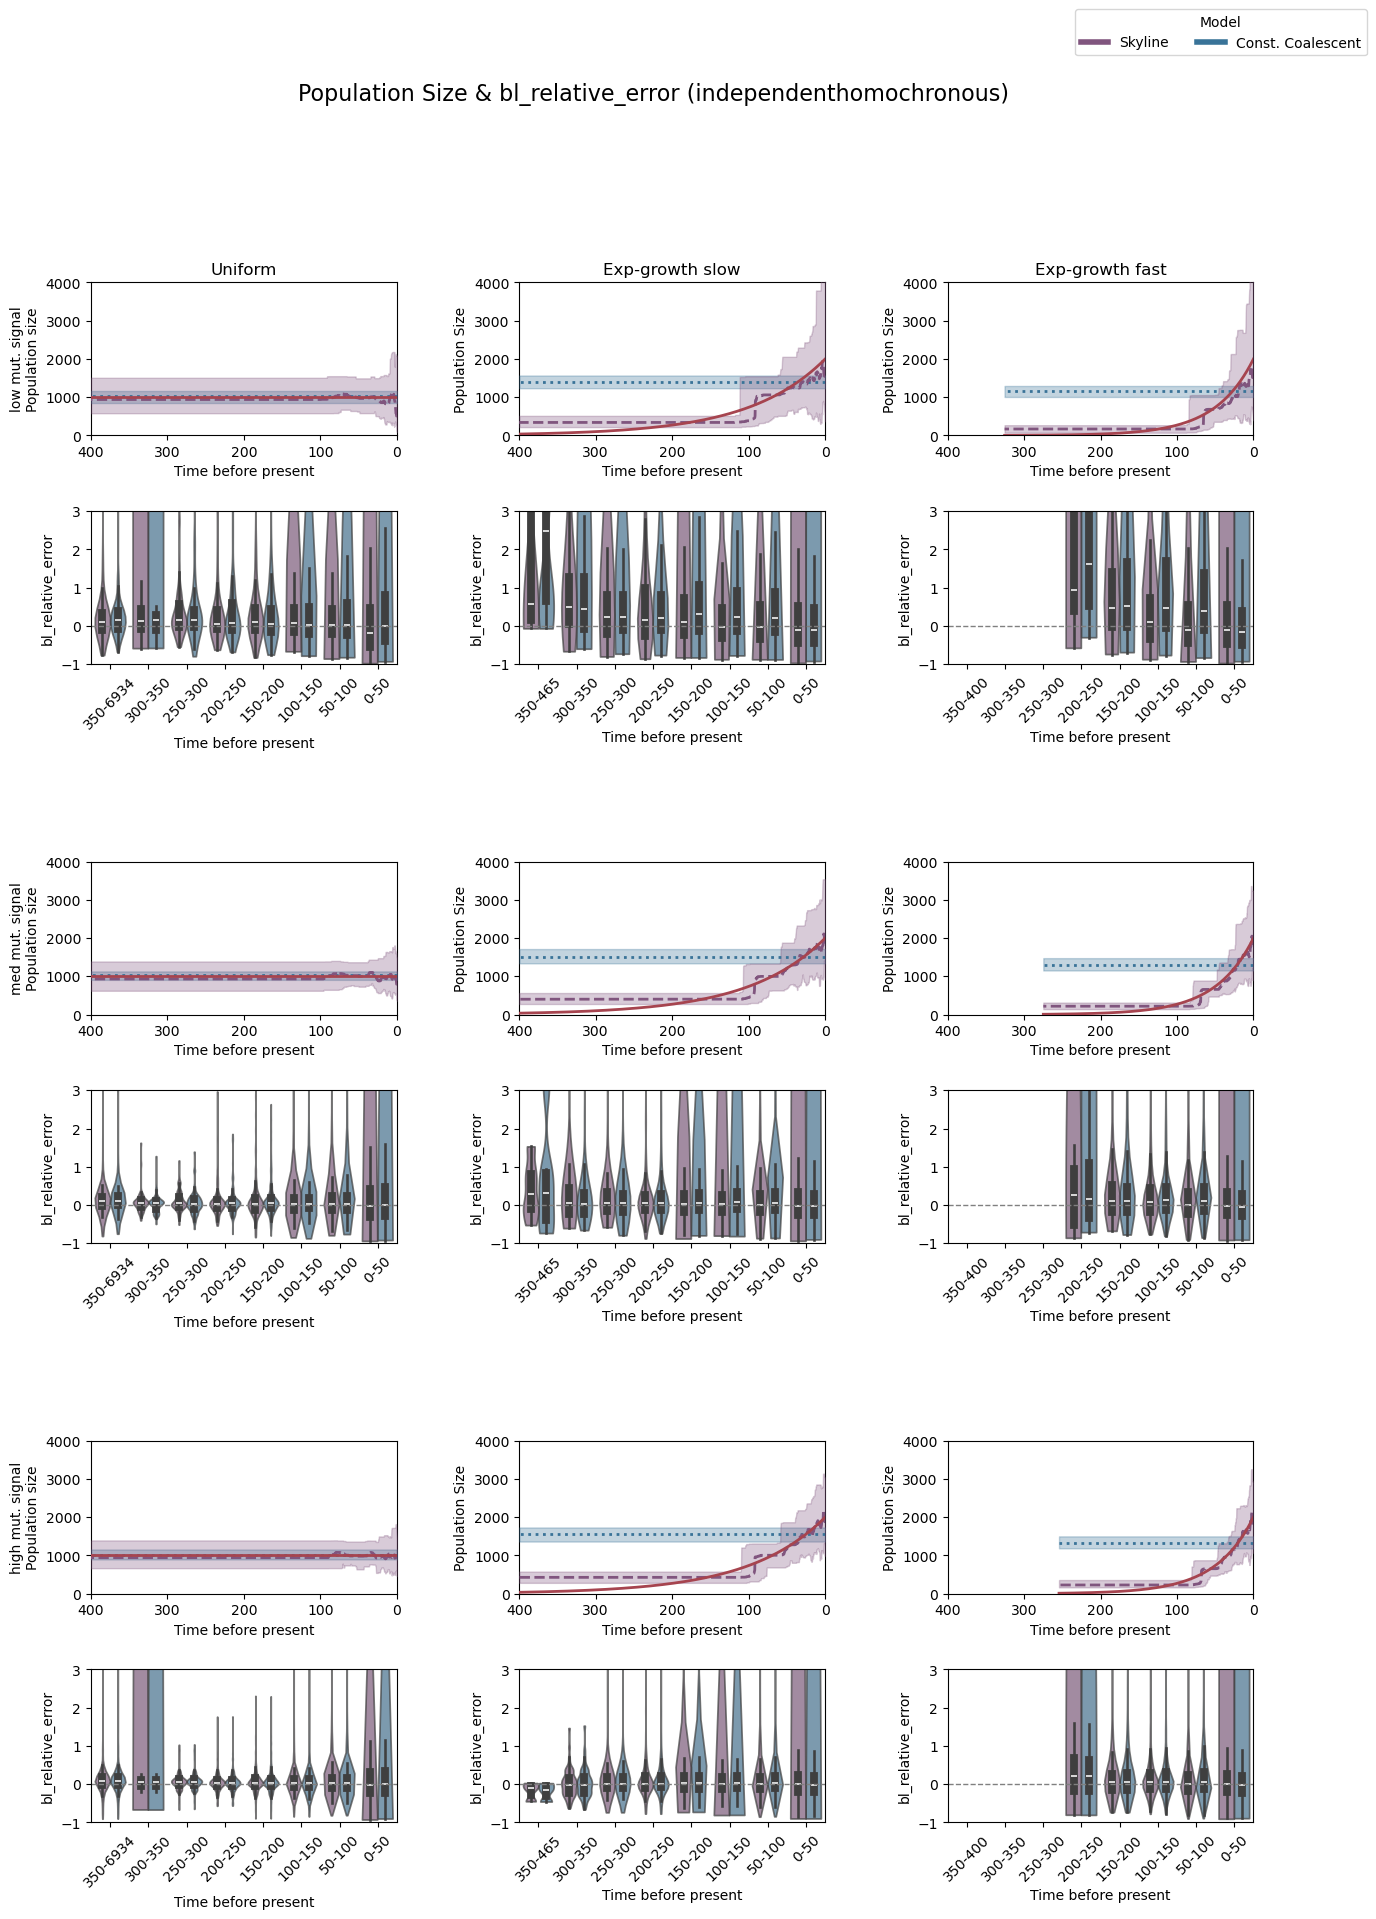

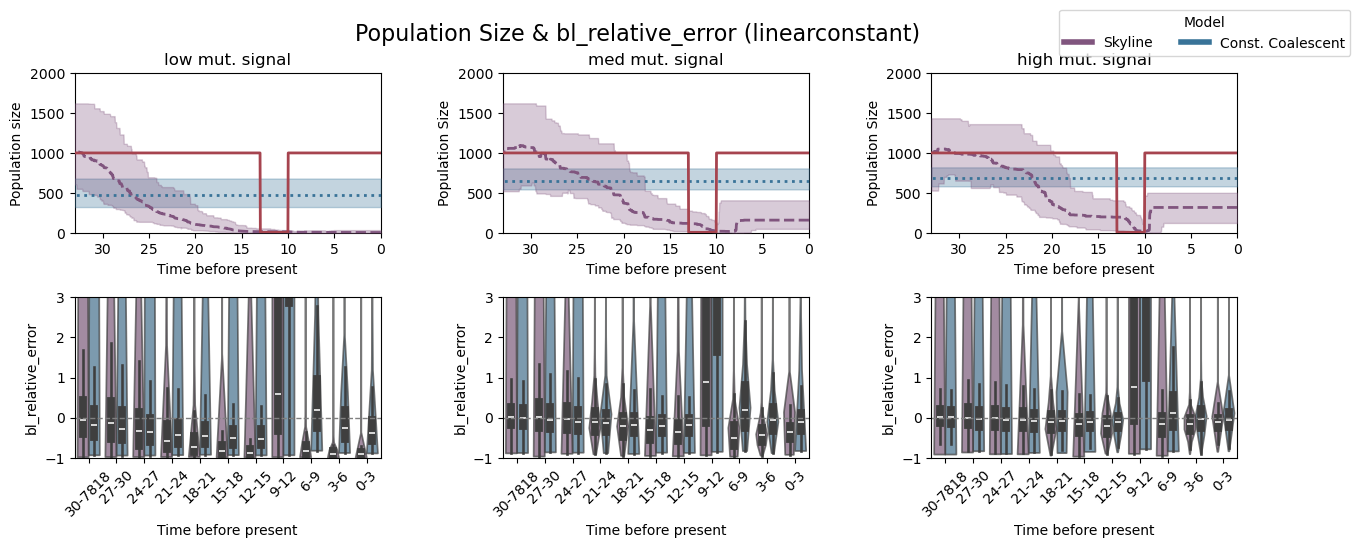

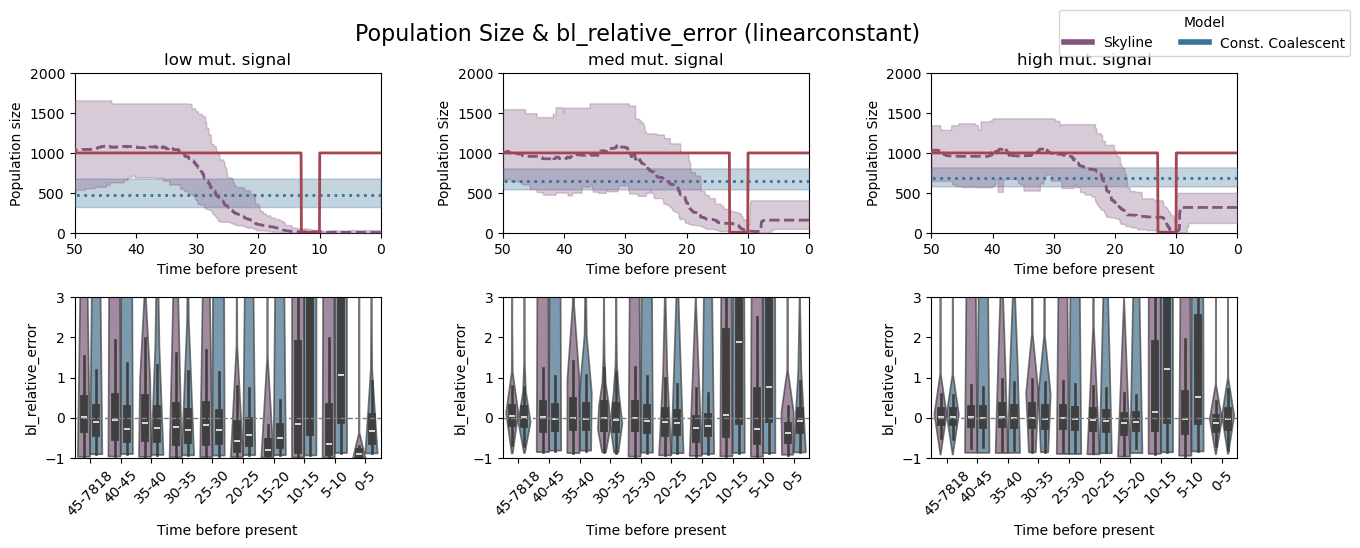

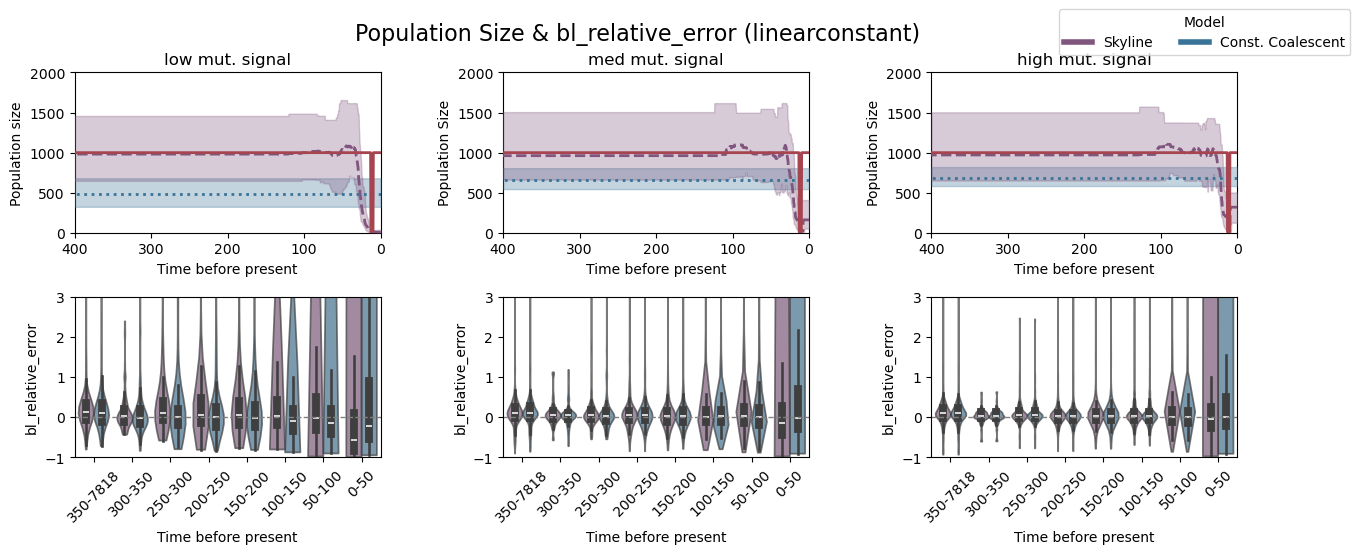

In [9]:
# branch lengths are plotted at the simulated (true) node height of the starting point of the branch, restricted to the last 100 years because that's where most of the population size changes happen and where we have most of the data points

plot_combined_population_and_error(
    df_population=overview_df_,
    df_error=tree_metrics_combined,
    pop_models=["uniform", "expgrowthslow", "expgrowthfast"],
    time_horizon=100,
    sampling="independenthomochronous",
    pop_y_range=(0, 4000),
    error_y_range=(-1, 3),
    bin_width=10,
    error_col="bl_relative_error",
    x_col="height_sim",
    plot_type="violin"
)

plot_combined_population_and_error(
    df_population=overview_df_,
    df_error=tree_metrics_combined,
    time_horizon=400,
    pop_models=["uniform", "expgrowthslow", "expgrowthfast"],
    sampling="independenthomochronous",
    pop_y_range=(0, 4000),
    error_y_range=(-1, 3),
    bin_width=50,
    error_col="bl_relative_error",
    x_col="height_sim",
    plot_type="violin"
)

plot_combined_population_and_error(
    df_population=overview_df_,
    df_error=tree_metrics_combined,
    pop_models = ['bottleneck'],
    time_horizon=33,
    sampling="linearconstant",
    pop_y_range=(0, 2000),
    error_y_range=(-1, 3),
    bin_width=3,
    error_col="bl_relative_error",
    x_col="height_sim",
    plot_type="violin"
)

plot_combined_population_and_error(
    df_population=overview_df_,
    df_error=tree_metrics_combined,
    pop_models = ['bottleneck'],
    time_horizon=50,
    sampling="linearconstant",
    pop_y_range=(0, 2000),
    error_y_range=(-1, 3),
    bin_width=5,
    error_col="bl_relative_error",
    x_col="height_sim",
    plot_type="violin"
)

plot_combined_population_and_error(
    df_population=overview_df_,
    df_error=tree_metrics_combined,
    pop_models = ['bottleneck'],
    time_horizon=400,
    sampling="linearconstant",
    pop_y_range=(0, 2000),
    error_y_range=(-1, 3),
    bin_width=50,
    error_col="bl_relative_error",
    x_col="height_sim",
    plot_type="violin"
)

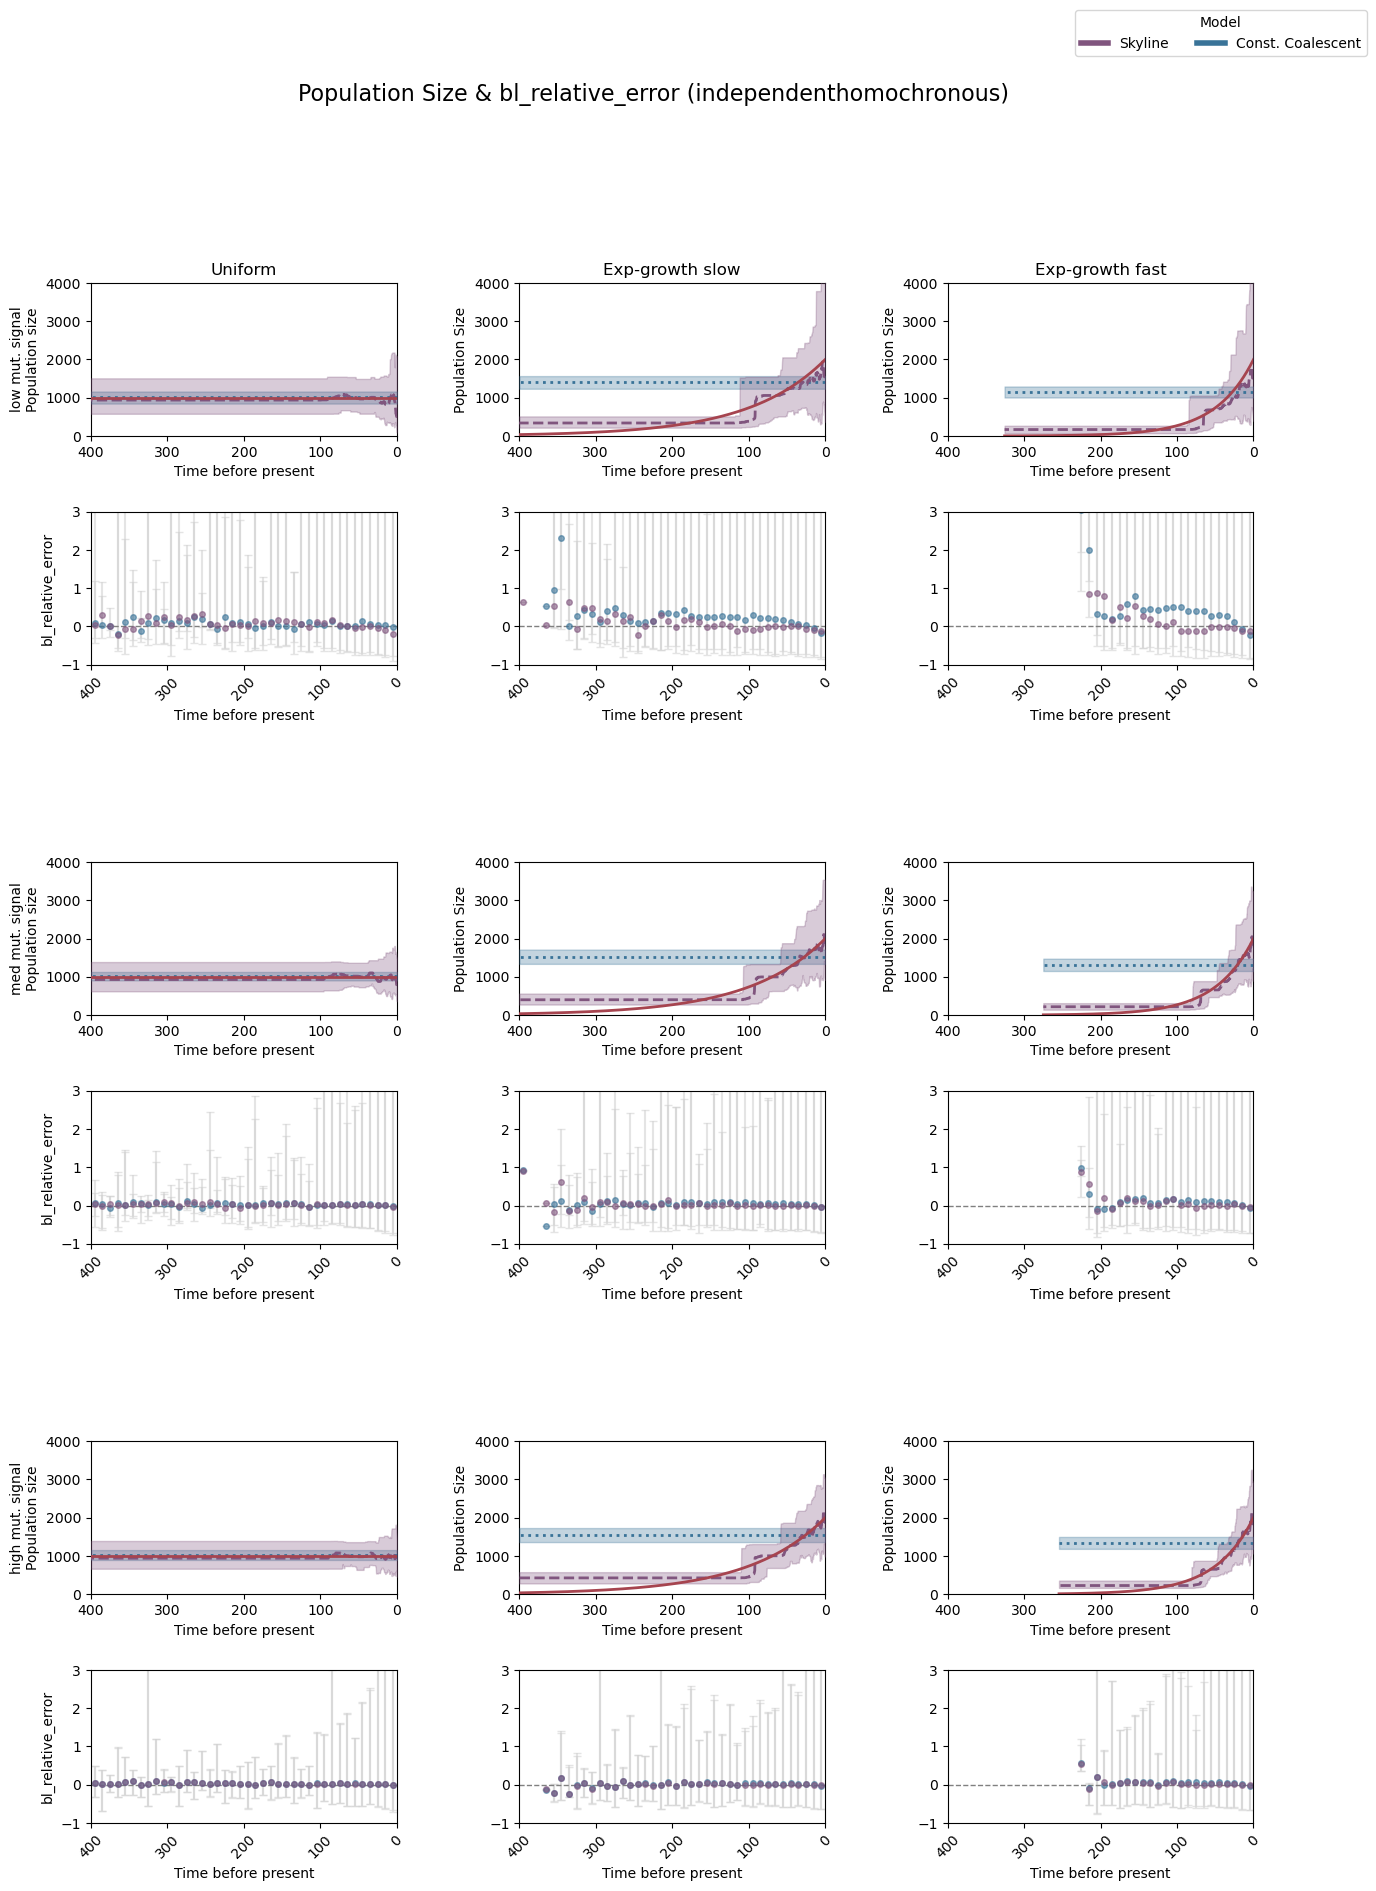

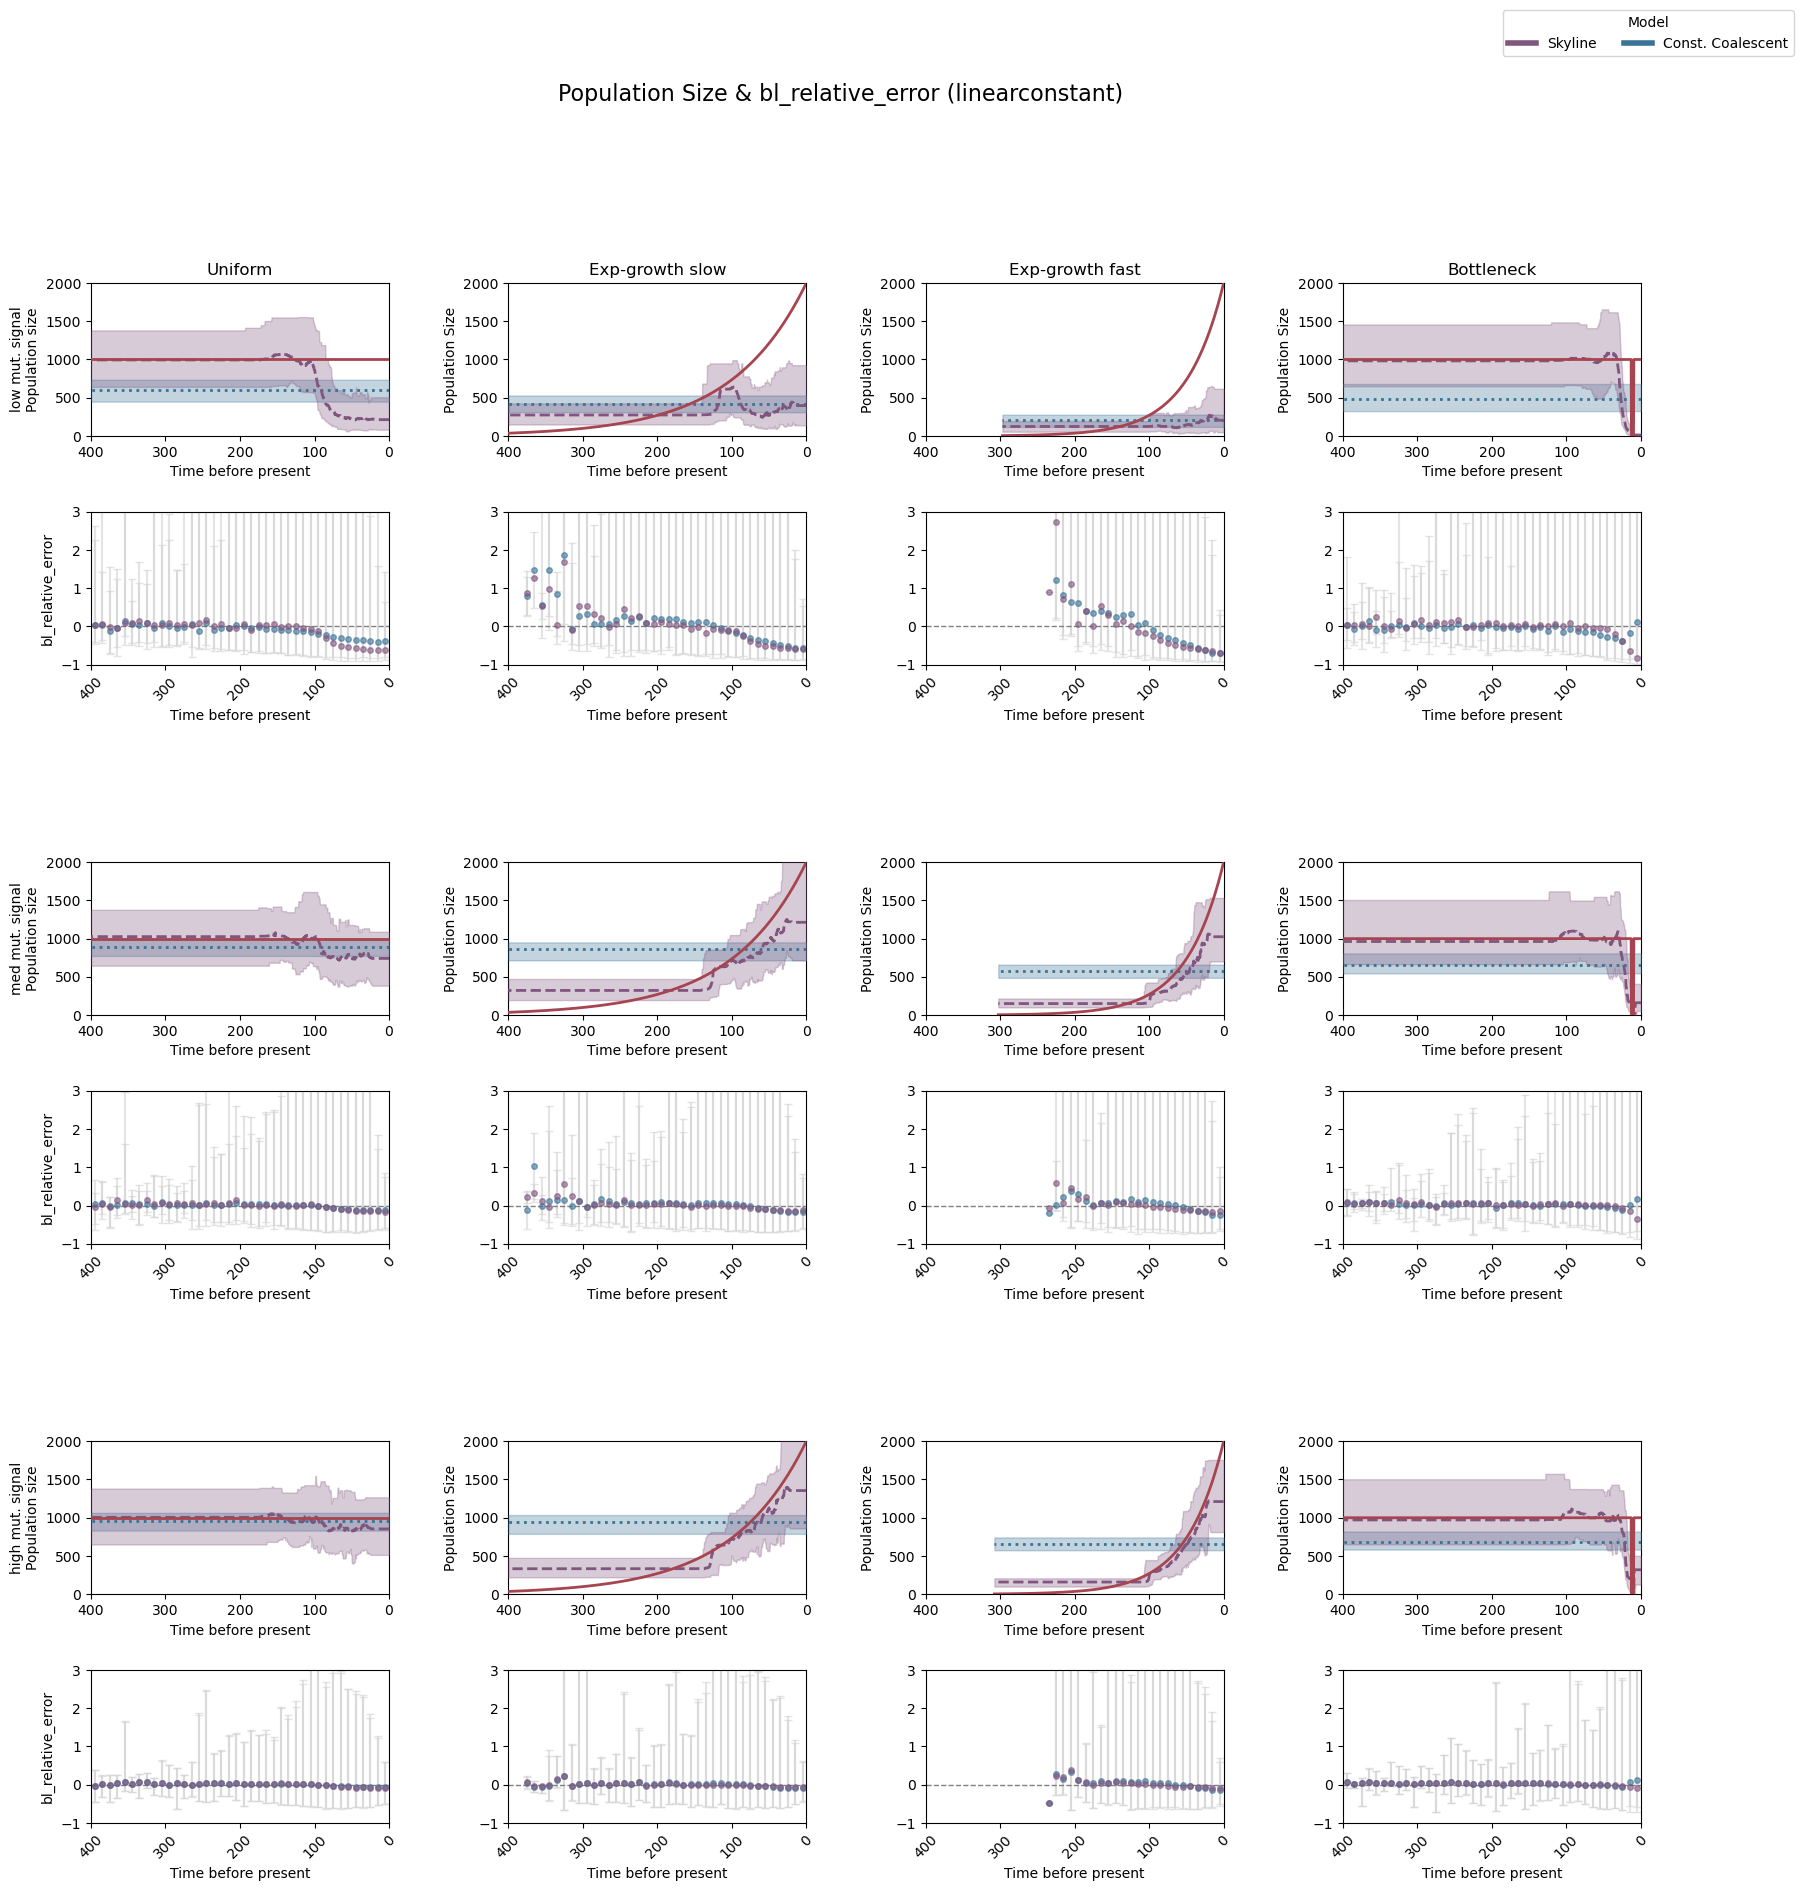

In [10]:
# scatter plot

plot_combined_population_and_error(
    df_population=overview_df_,
    df_error=tree_metrics_combined,
    pop_models=["uniform", "expgrowthslow", "expgrowthfast"],
    time_horizon=400,
    sampling="independenthomochronous",
    pop_y_range=(0, 4000),
    error_y_range=(-1, 3),
    bin_width=10,
    error_col="bl_relative_error",
    x_col="height_sim",
    plot_type="scatter"
)

plot_combined_population_and_error(
    df_population=overview_df_,
    df_error=tree_metrics_combined,
    time_horizon=400,
    sampling="linearconstant",
    pop_y_range=(0, 2000),
    error_y_range=(-1, 3),
    bin_width=10,
    error_col="bl_relative_error",
    x_col="height_sim",
    plot_type="scatter"
)

# Compare population error and Branch Length error

Observations:
- higher error in population size leads to a higher relative error in branch length
- skyline model lead to under and overestimation in population size while constatant population model nearly always overestimates the error
- for uniform population size, constant coal leads to a less high error in population size compared to skyline but not in branch length, opposite effect for exponential growth
- generally skyline seems to lead to a bit lower errors for low mutation signal exp growth case
- when binning on non absolute errors, for skyline some errors cancel each other out, which is why we see less of an effect on absolute errors

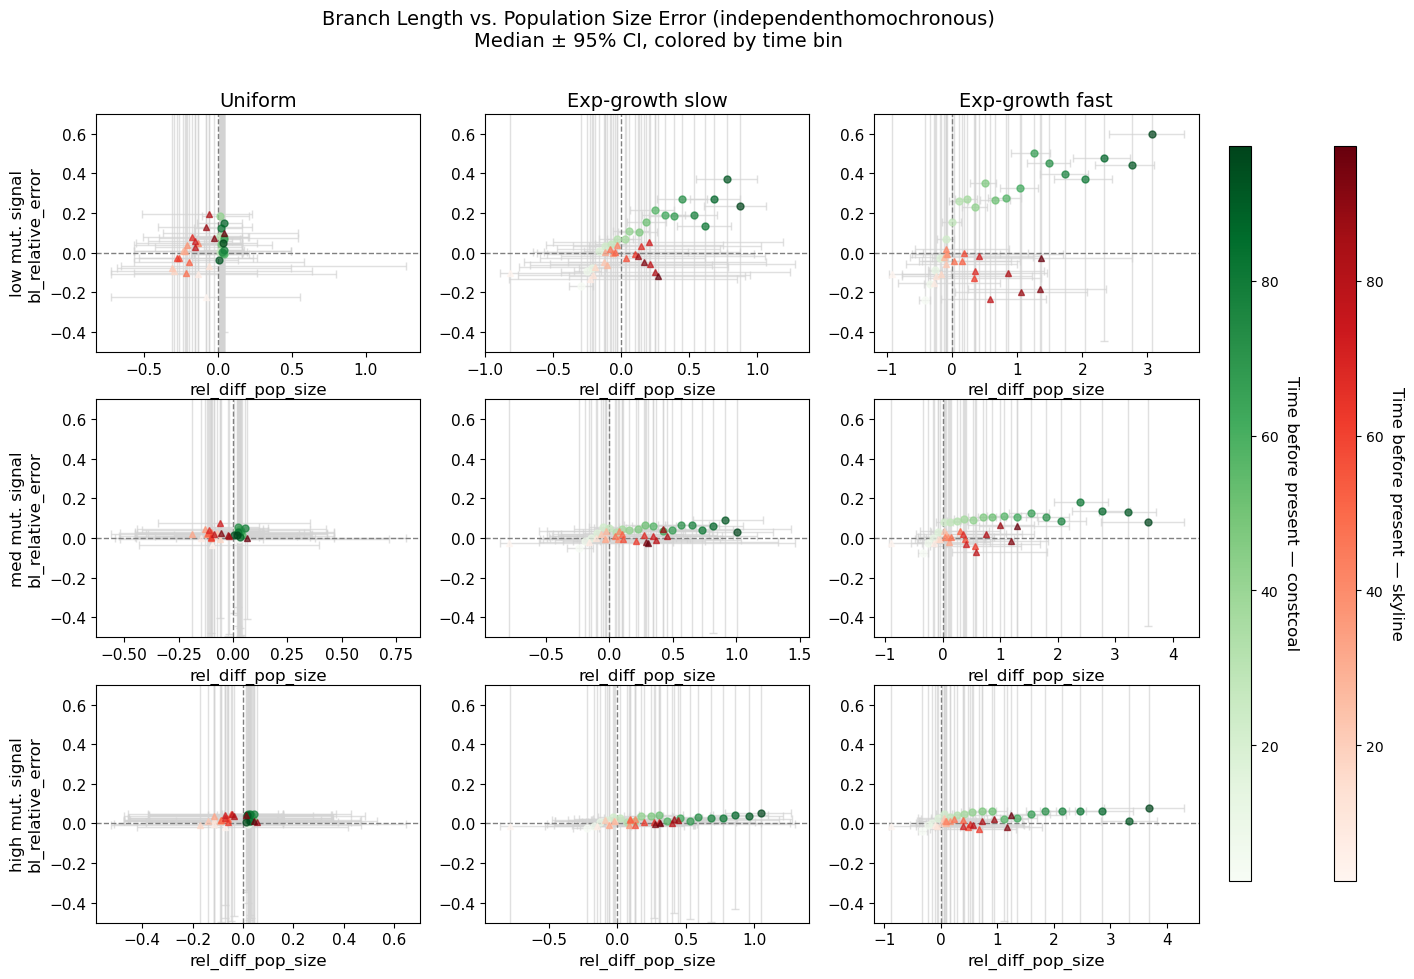

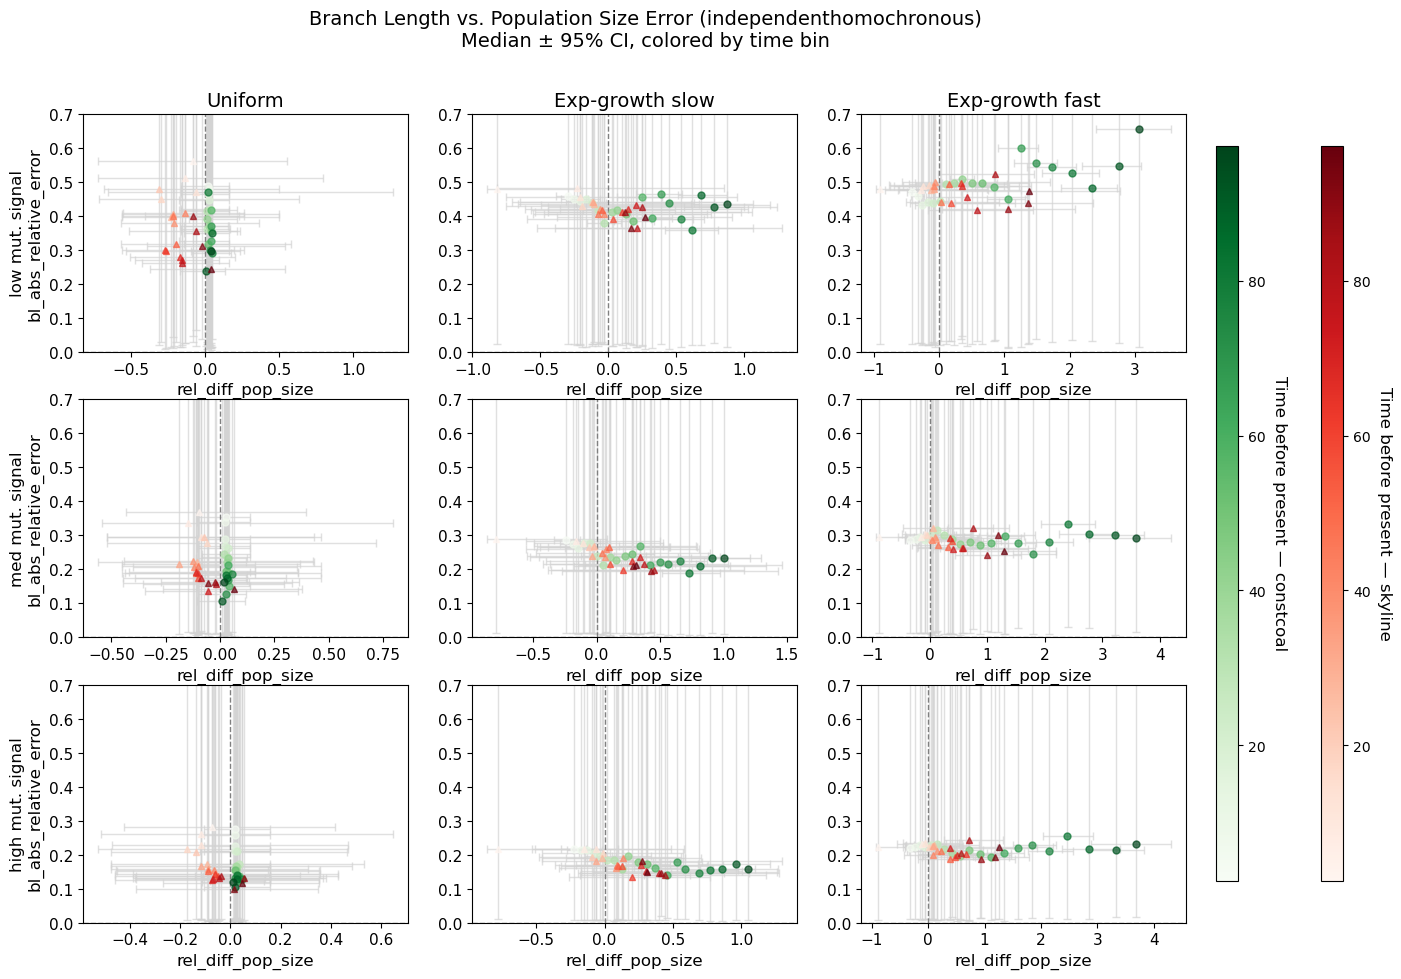

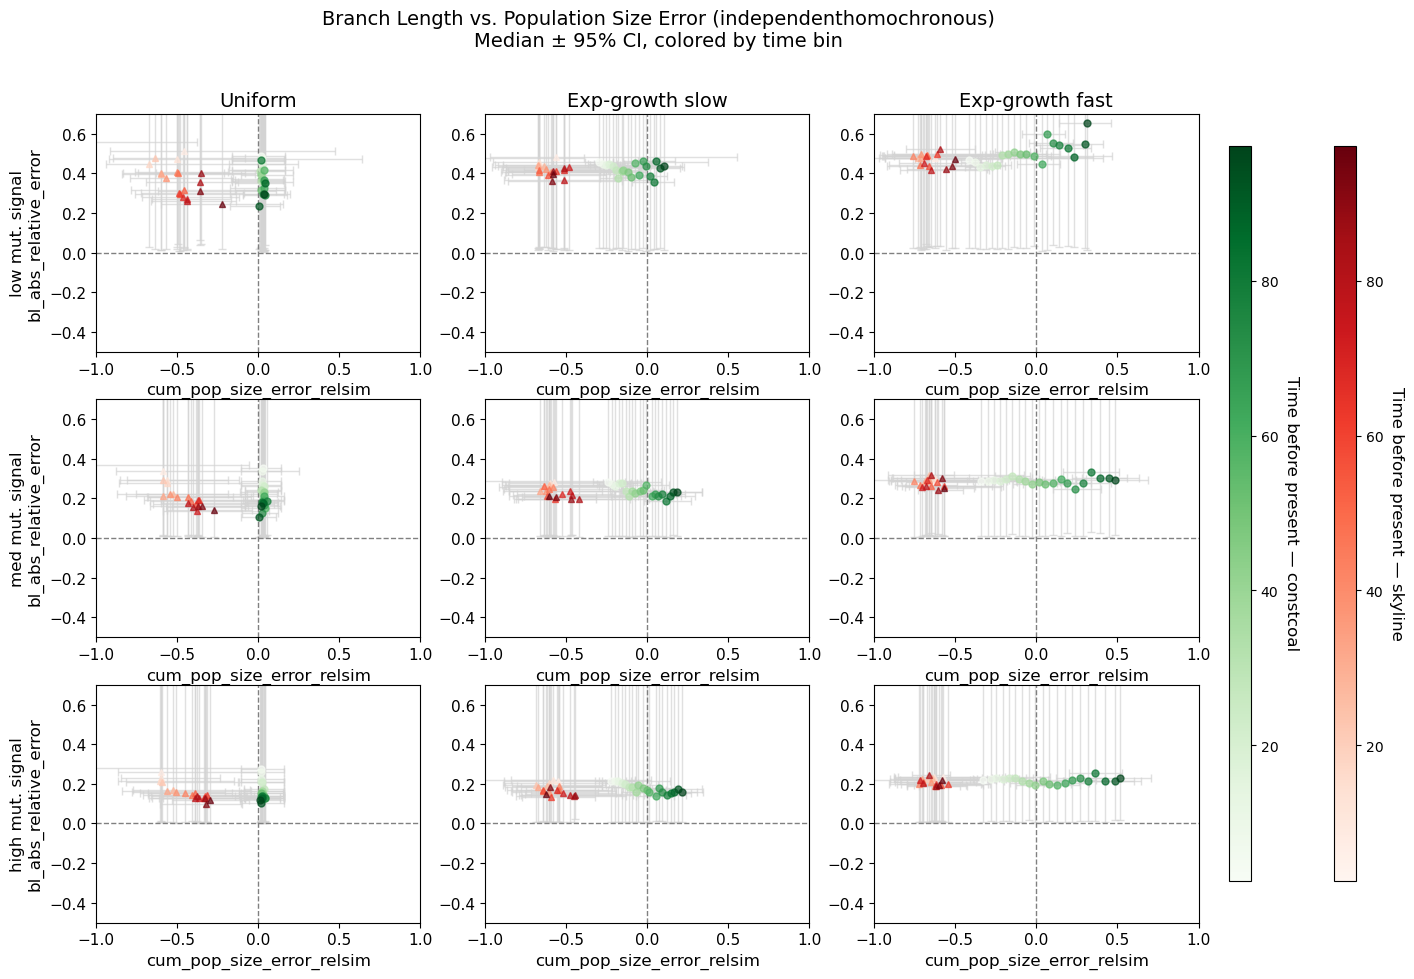

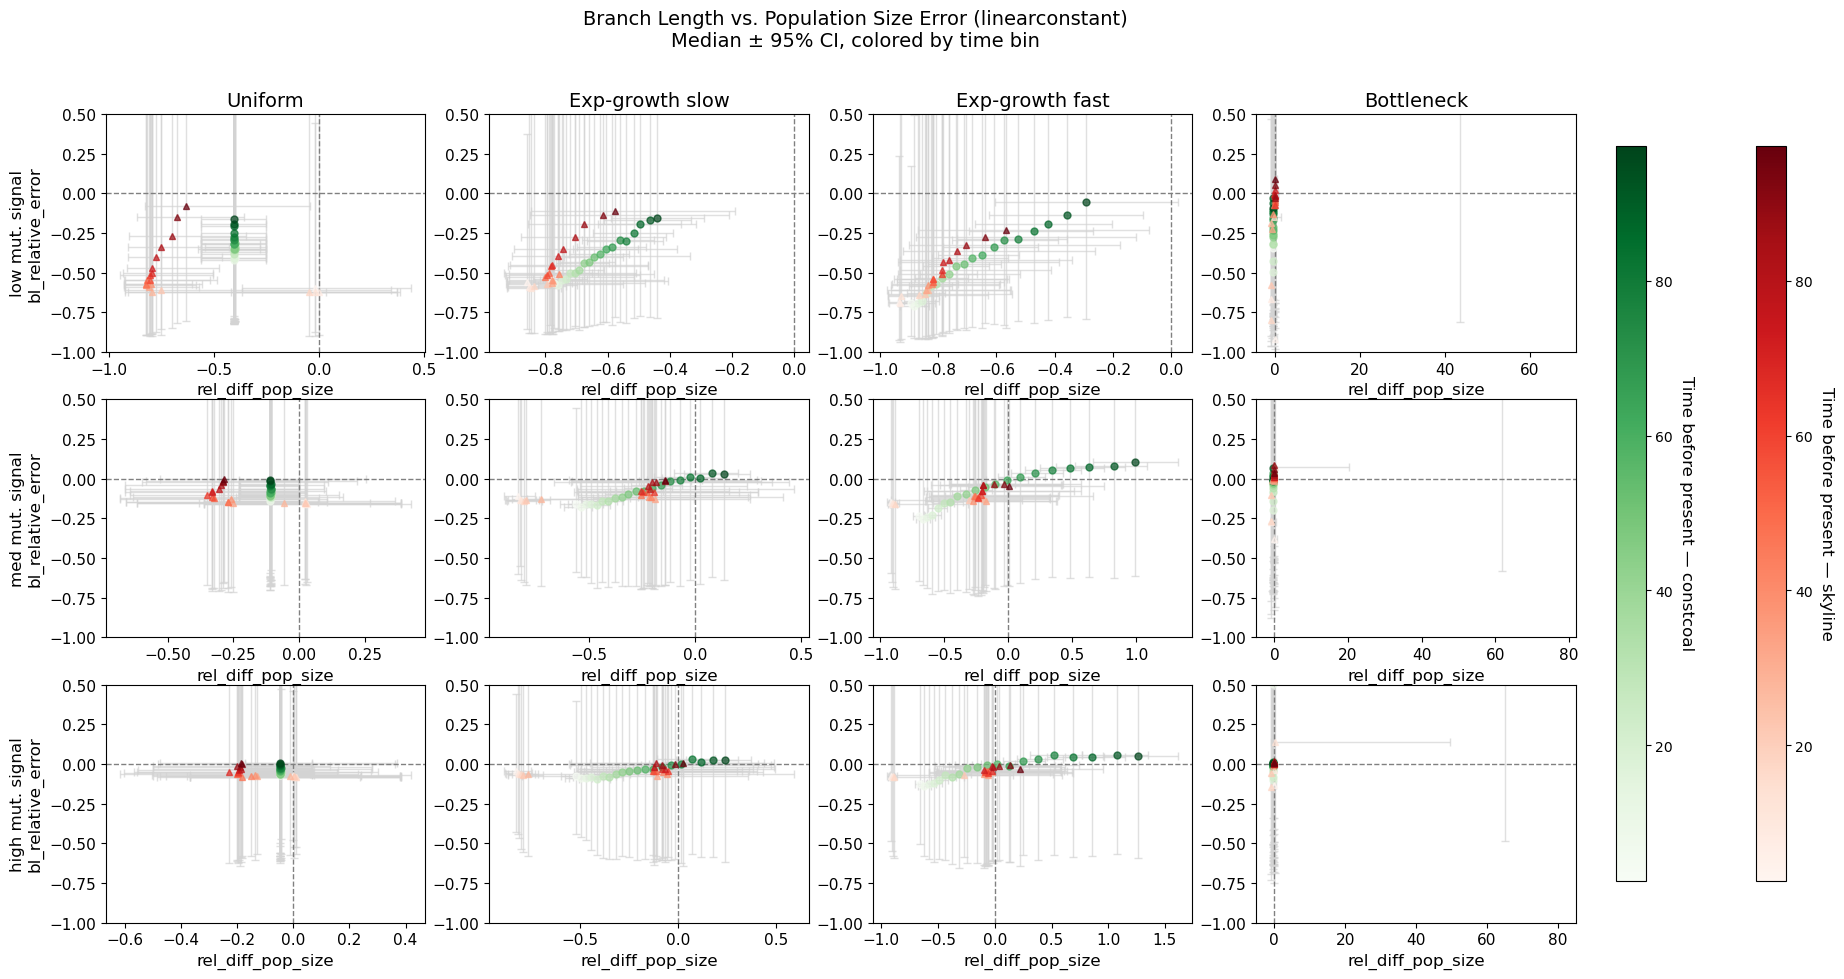

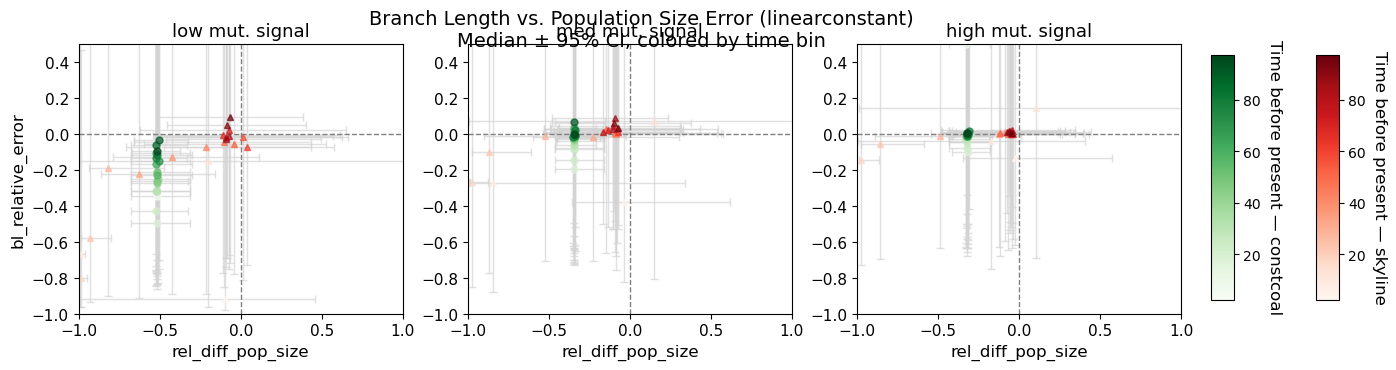

In [15]:
# only keep bins with at least 10 values, restricted to the last 100 years, bin_width = 5

plot_bl_vs_popsize_error_timecoloring_dualmodel(tree_metrics_combined, sampling = "independenthomochronous", bin_width=5, time_col="height_sim",
                                                    pop_error_col="rel_diff_pop_size", bl_error_col="bl_relative_error", min_values_per_bin = 10,
                                                    x_range=None, y_range=(-0.5,0.7), show_errorbars=True, time_limit = 100, log_colorbar = False,
                                                    pop_models = ['uniform', 'expgrowthslow', 'expgrowthfast'])

plot_bl_vs_popsize_error_timecoloring_dualmodel(tree_metrics_combined, sampling = "independenthomochronous", bin_width=5, time_col="height_sim",
                                                    pop_error_col="rel_diff_pop_size", bl_error_col="bl_abs_relative_error", min_values_per_bin = 10,
                                                    x_range=None, y_range=(0,0.7), show_errorbars=True, time_limit = 100, log_colorbar = False,
                                                    pop_models = ['uniform', 'expgrowthslow', 'expgrowthfast'])

plot_bl_vs_popsize_error_timecoloring_dualmodel(tree_metrics_combined, sampling = "independenthomochronous", bin_width=5, time_col="height_sim",
                                                    pop_error_col="cum_pop_size_error_relsim", bl_error_col="bl_abs_relative_error", min_values_per_bin = 10,
                                                    x_range=(-1,1), y_range=(-0.5,0.7), show_errorbars=True, time_limit = 100, log_colorbar = False,
                                                    pop_models = ['uniform', 'expgrowthslow', 'expgrowthfast'])

plot_bl_vs_popsize_error_timecoloring_dualmodel(tree_metrics_combined, sampling = "linearconstant", bin_width=5, time_col="height_sim",
                                                    pop_error_col="rel_diff_pop_size", bl_error_col="bl_relative_error", min_values_per_bin = 10,
                                                    x_range=None, y_range=(-1,0.5), show_errorbars=True, time_limit = 100, log_colorbar = False,)

plot_bl_vs_popsize_error_timecoloring_dualmodel(tree_metrics_combined, sampling = "linearconstant", bin_width=5, time_col="height_sim",
                                                    pop_error_col="rel_diff_pop_size", bl_error_col="bl_relative_error", min_values_per_bin = 10,
                                                    x_range=(-1,1), y_range=(-1,0.5), show_errorbars=True, time_limit = 100, log_colorbar = False,
                                                    pop_models = ['bottleneck'])

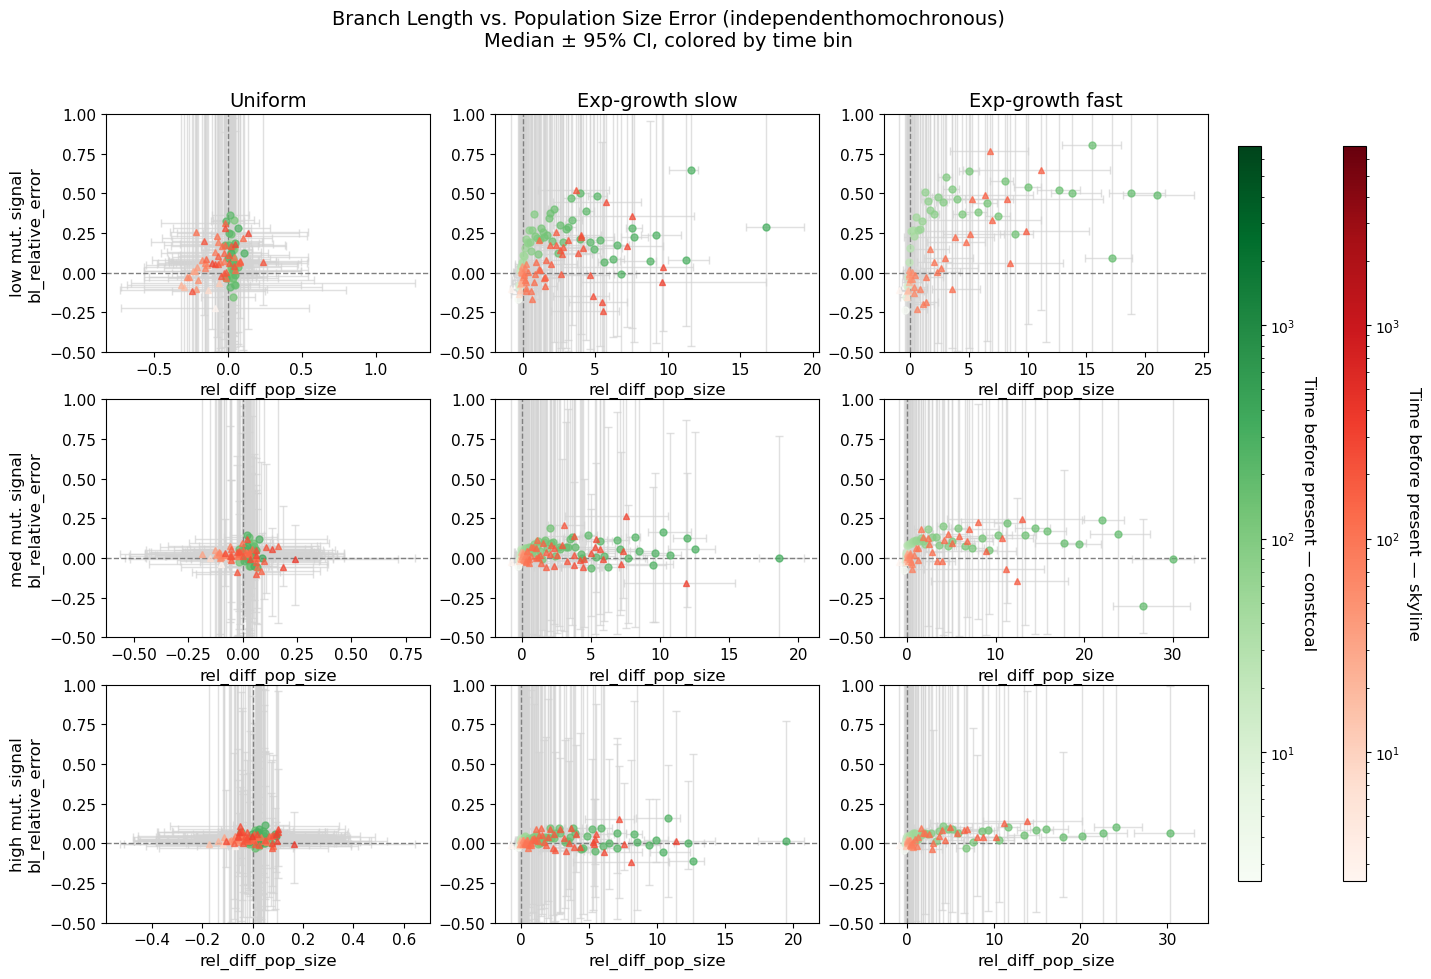

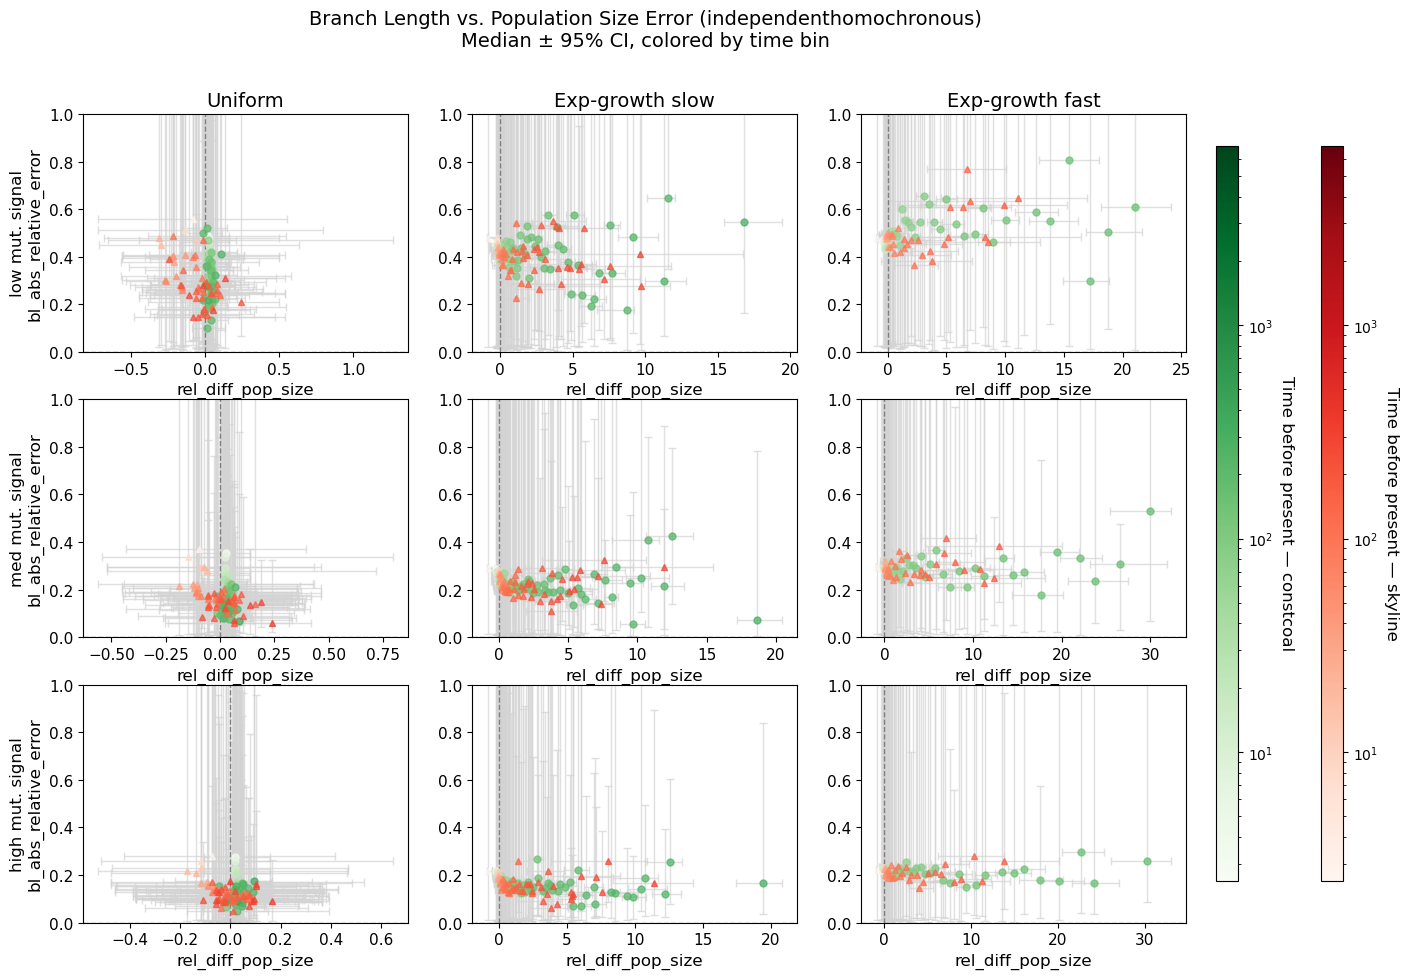

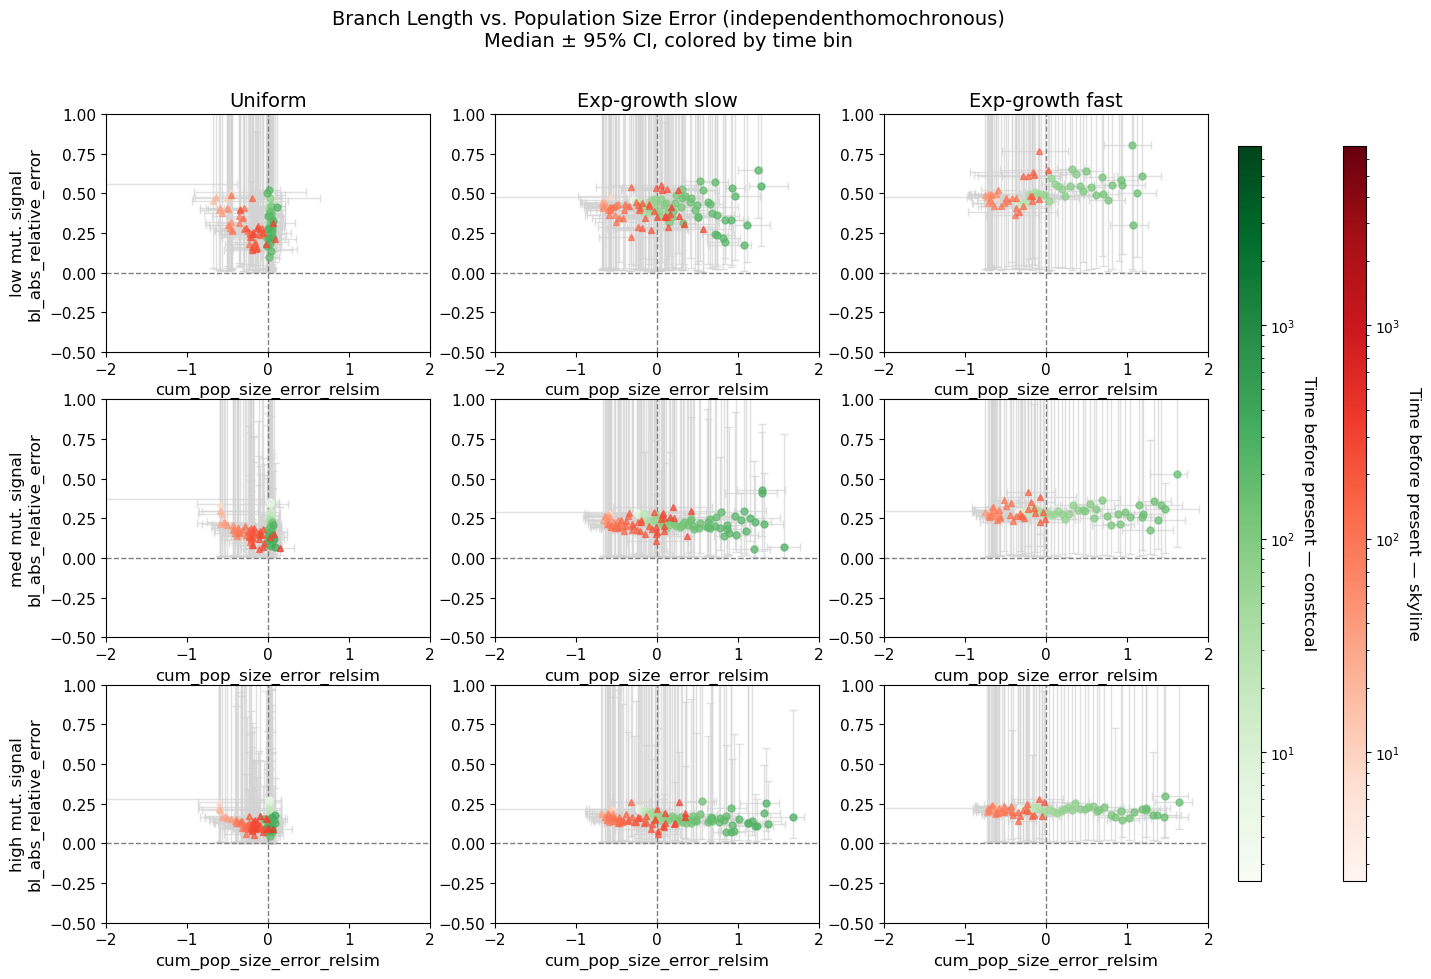

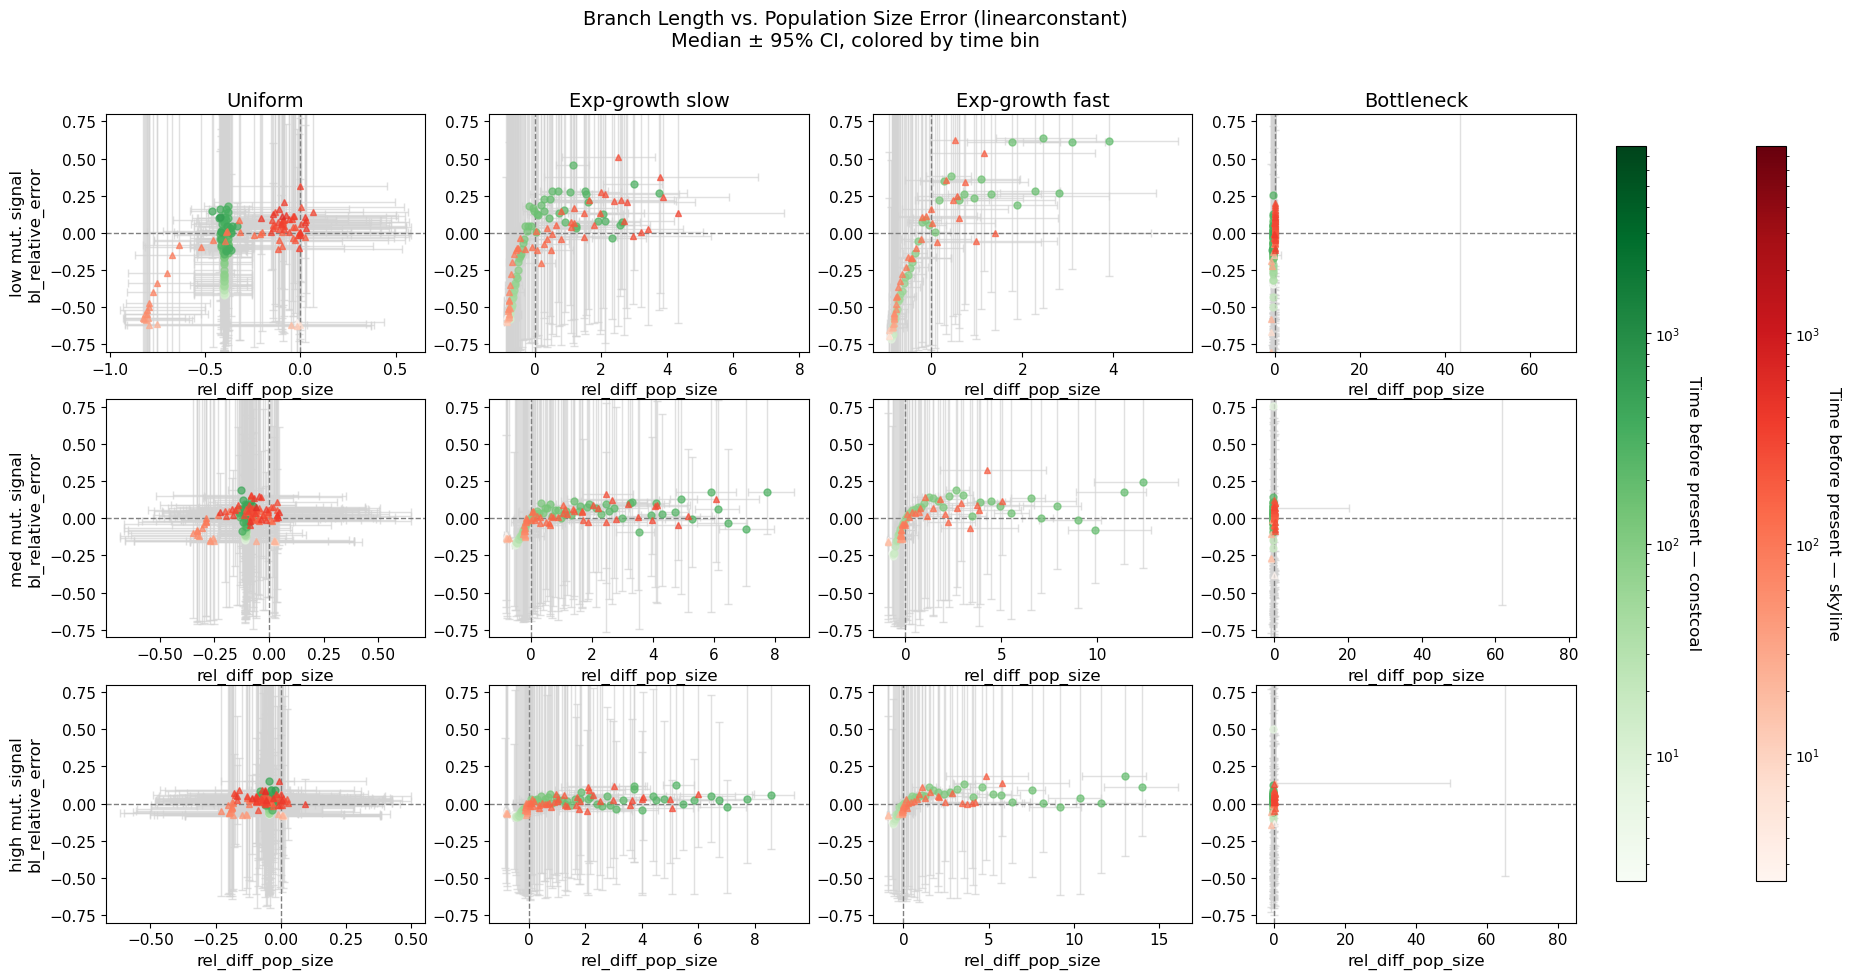

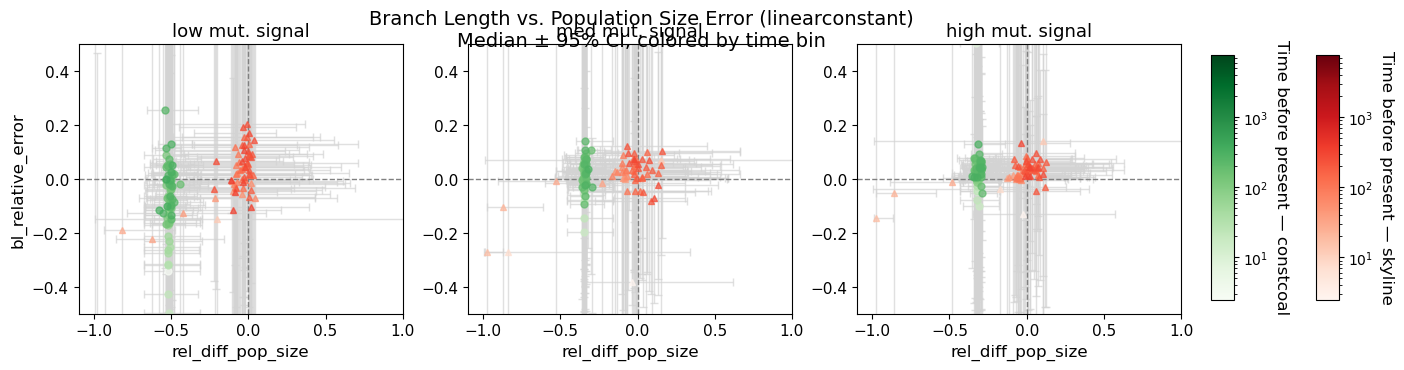

In [19]:
plot_bl_vs_popsize_error_timecoloring_dualmodel(tree_metrics_combined, sampling = "independenthomochronous", bin_width=5, time_col="height_sim",
                                                    pop_error_col="rel_diff_pop_size", bl_error_col="bl_relative_error", min_values_per_bin = 10,
                                                    x_range=None, y_range=(-0.5,1), show_errorbars=True, time_limit = None, log_colorbar = True,
                                                    pop_models = ['uniform', 'expgrowthslow', 'expgrowthfast'])

plot_bl_vs_popsize_error_timecoloring_dualmodel(tree_metrics_combined, sampling = "independenthomochronous", bin_width=5, time_col="height_sim",
                                                    pop_error_col="rel_diff_pop_size", bl_error_col="bl_abs_relative_error", min_values_per_bin = 10,
                                                    x_range=None, y_range=(0,1), show_errorbars=True, time_limit = None, log_colorbar = True,
                                                    pop_models = ['uniform', 'expgrowthslow', 'expgrowthfast'])

plot_bl_vs_popsize_error_timecoloring_dualmodel(tree_metrics_combined, sampling = "independenthomochronous", bin_width=5, time_col="height_sim",
                                                    pop_error_col="cum_pop_size_error_relsim", bl_error_col="bl_abs_relative_error", min_values_per_bin = 10,
                                                    x_range=(-2,2), y_range=(-0.5,1), show_errorbars=True, time_limit = None, log_colorbar = True,
                                                    pop_models = ['uniform', 'expgrowthslow', 'expgrowthfast'])

plot_bl_vs_popsize_error_timecoloring_dualmodel(tree_metrics_combined, sampling = "linearconstant", bin_width=5, time_col="height_sim",
                                                    pop_error_col="rel_diff_pop_size", bl_error_col="bl_relative_error", min_values_per_bin = 10,
                                                    x_range=None, y_range=(-0.8,0.8), show_errorbars=True, time_limit = None, log_colorbar = True,)

plot_bl_vs_popsize_error_timecoloring_dualmodel(tree_metrics_combined, sampling = "linearconstant", bin_width=5, time_col="height_sim",
                                                    pop_error_col="rel_diff_pop_size", bl_error_col="bl_relative_error", min_values_per_bin = 10,
                                                    x_range=(-1.1,1), y_range=(-0.5,0.5), show_errorbars=True, time_limit = None, log_colorbar = True,
                                                    pop_models = ['bottleneck'])

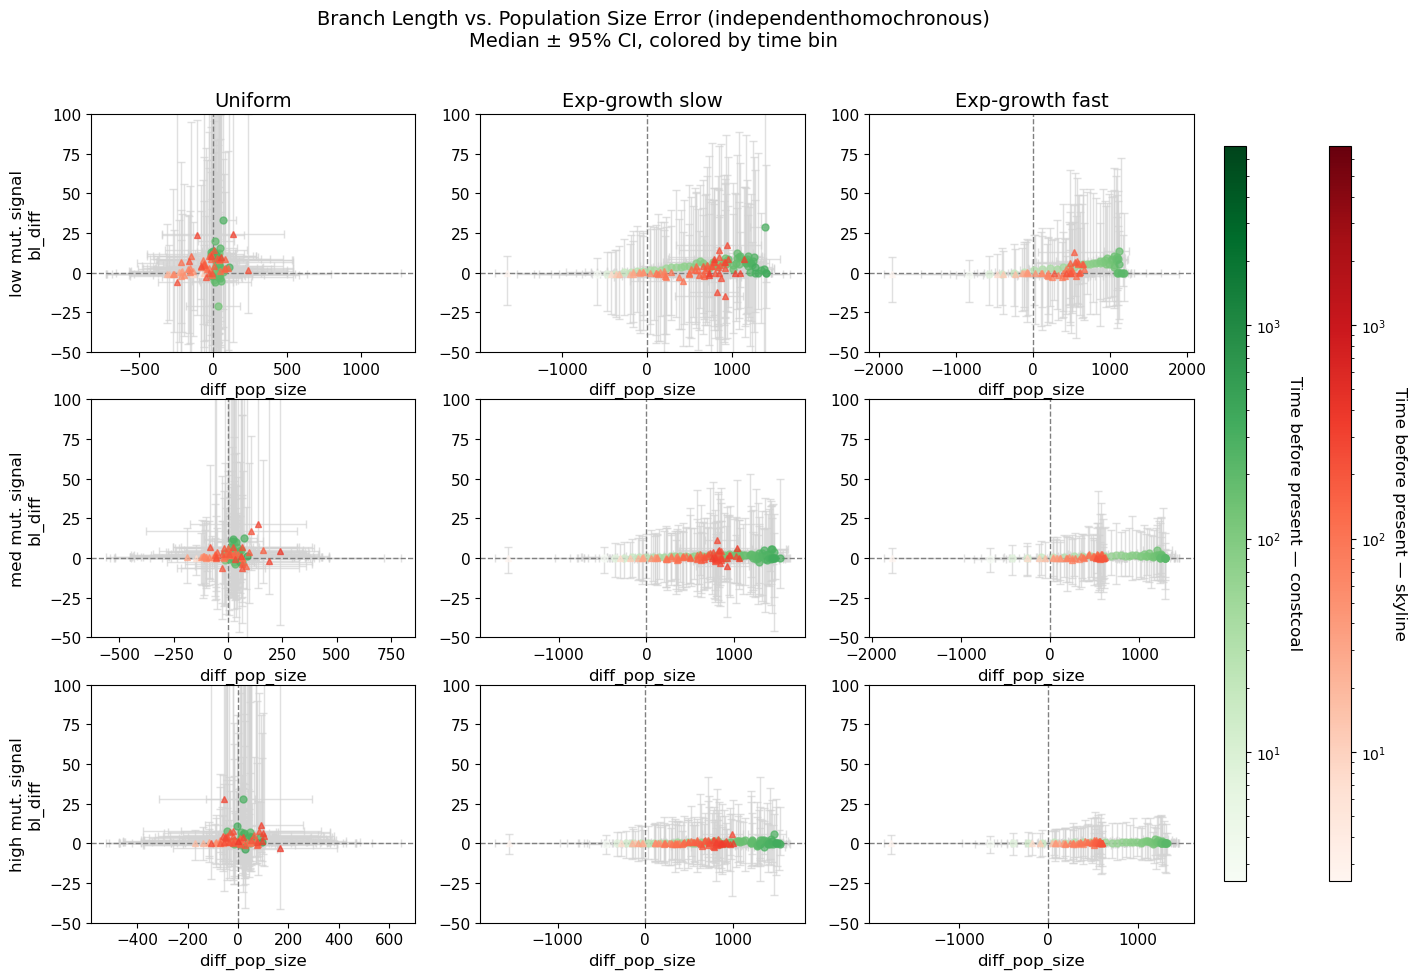

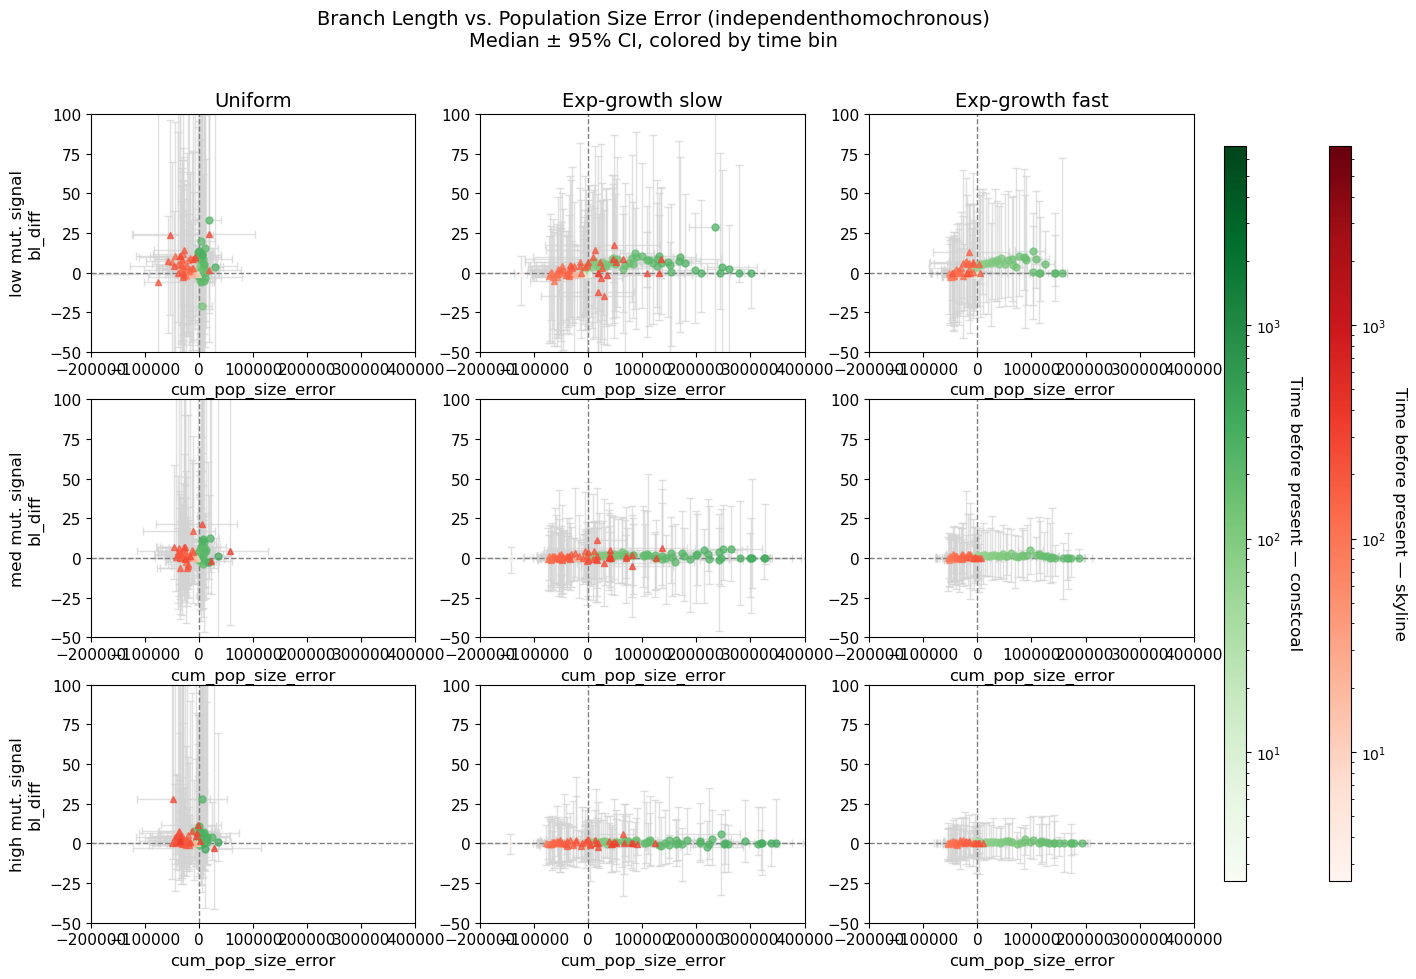

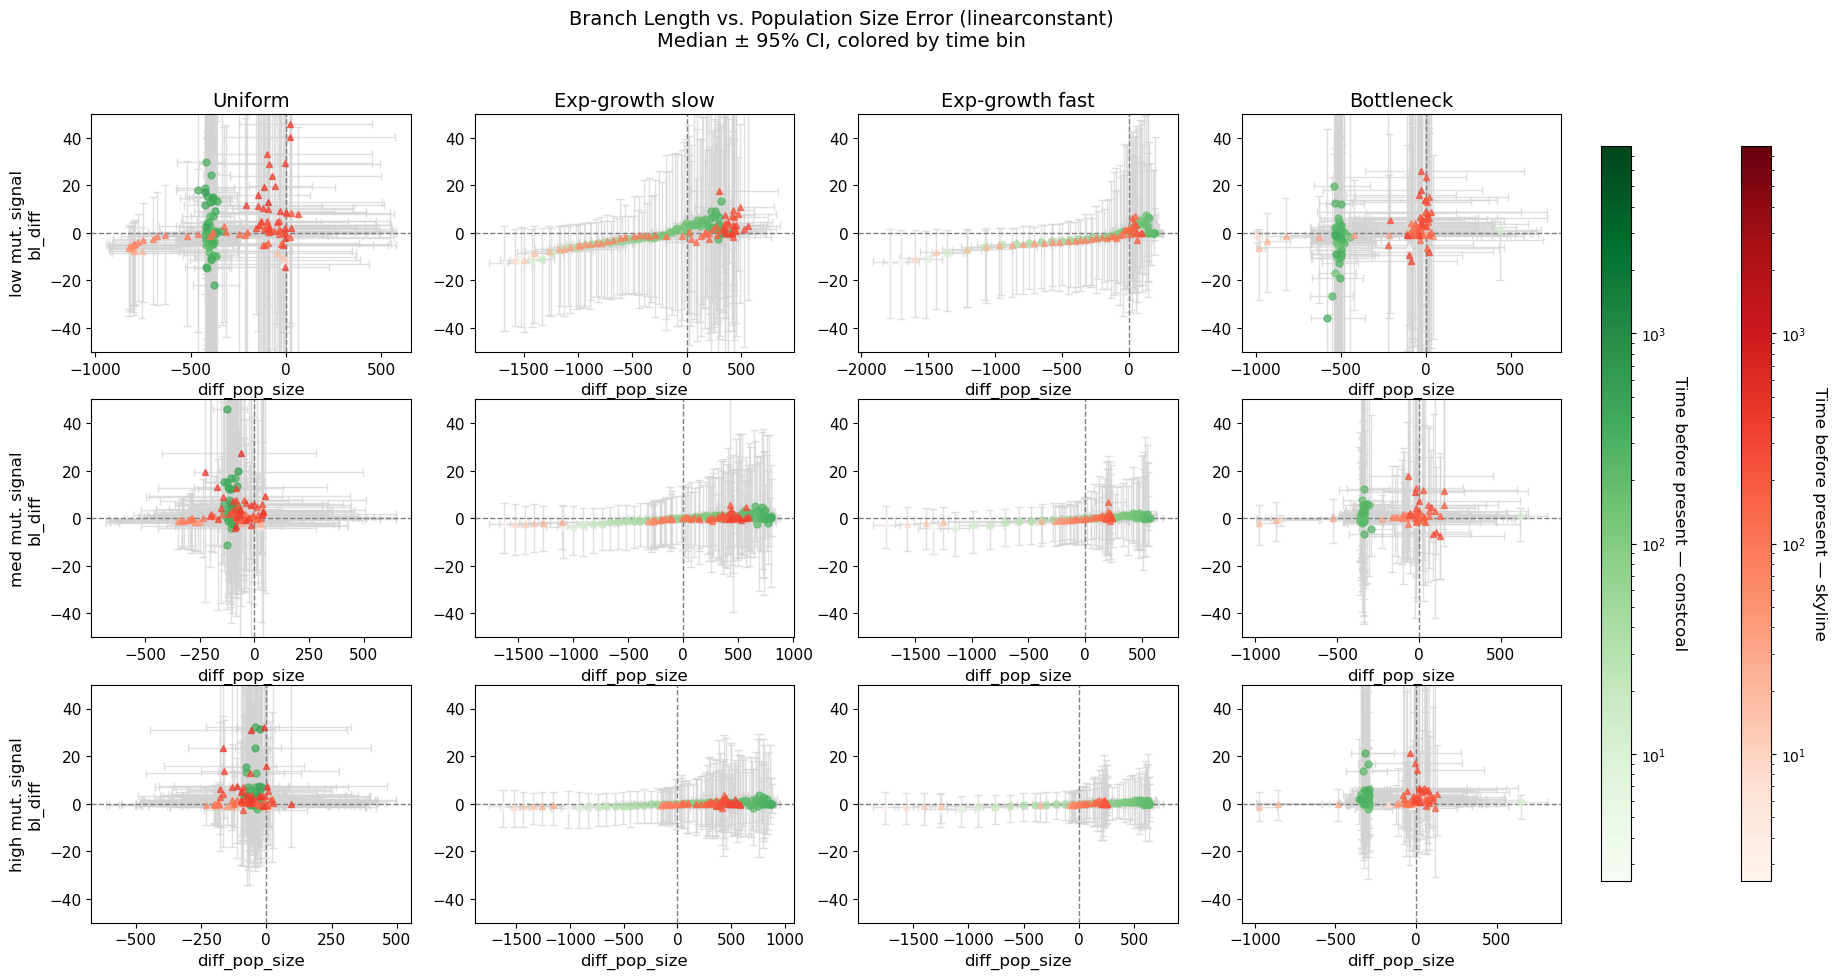

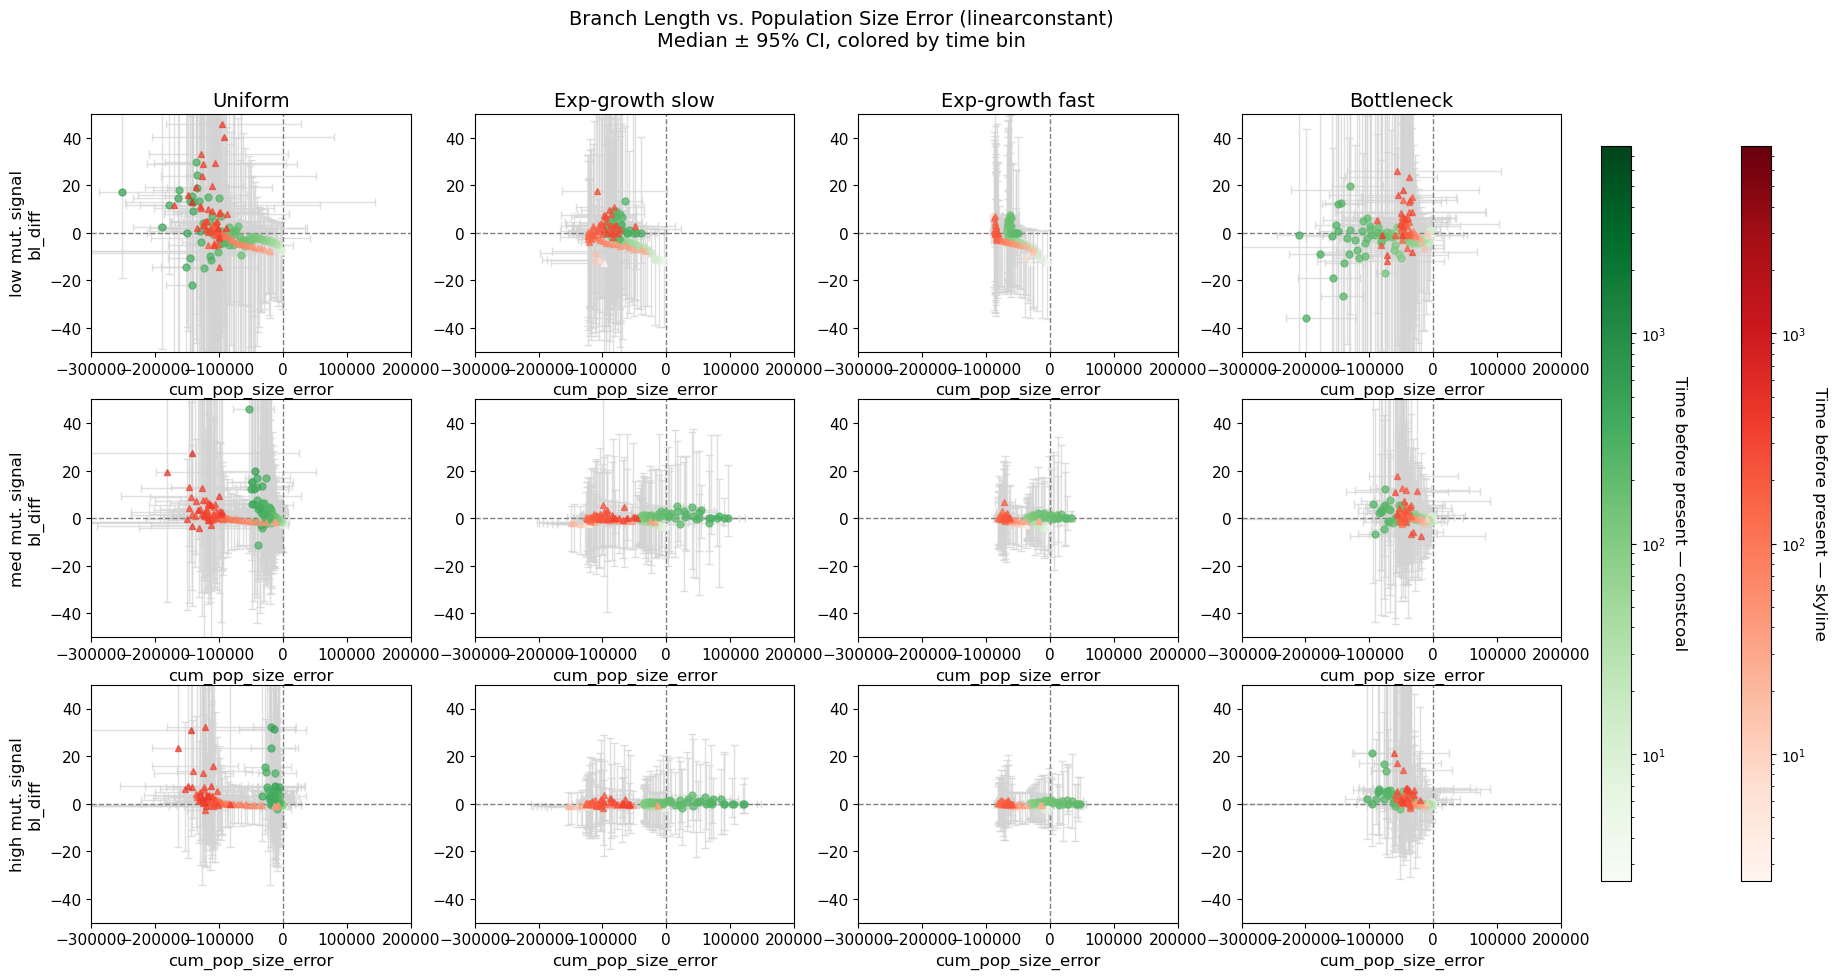

In [22]:
# only keep bins with at least 10 values, bin_width = 5

plot_bl_vs_popsize_error_timecoloring_dualmodel(tree_metrics_combined, sampling = "independenthomochronous", bin_width=5, time_col="height_sim",
                                                    pop_error_col="diff_pop_size", bl_error_col="bl_diff", min_values_per_bin = 10,
                                                    x_range=None, y_range=(-50,100), show_errorbars=True, time_limit = None, log_colorbar = True,
                                                    pop_models = ['uniform', 'expgrowthslow', 'expgrowthfast'])

plot_bl_vs_popsize_error_timecoloring_dualmodel(tree_metrics_combined, sampling = "independenthomochronous", bin_width=5, time_col="height_sim",
                                                    pop_error_col="cum_pop_size_error", bl_error_col="bl_diff", min_values_per_bin = 10,
                                                    x_range=(-200000,400000), y_range=(-50,100), show_errorbars=True, time_limit = None, log_colorbar = True,
                                                    pop_models = ['uniform', 'expgrowthslow', 'expgrowthfast'])

plot_bl_vs_popsize_error_timecoloring_dualmodel(tree_metrics_combined, sampling = "linearconstant", bin_width=5, time_col="height_sim",
                                                    pop_error_col="diff_pop_size", bl_error_col="bl_diff", min_values_per_bin = 10,
                                                    x_range=None, y_range=(-50,50), show_errorbars=True, time_limit = None, log_colorbar = True)
                                                    
plot_bl_vs_popsize_error_timecoloring_dualmodel(tree_metrics_combined, sampling = "linearconstant", bin_width=5, time_col="height_sim",
                                                    pop_error_col="cum_pop_size_error", bl_error_col="bl_diff", min_values_per_bin = 10,
                                                    x_range=(-300000, 200000), y_range=(-50,50), show_errorbars=True, time_limit = None, log_colorbar = True)

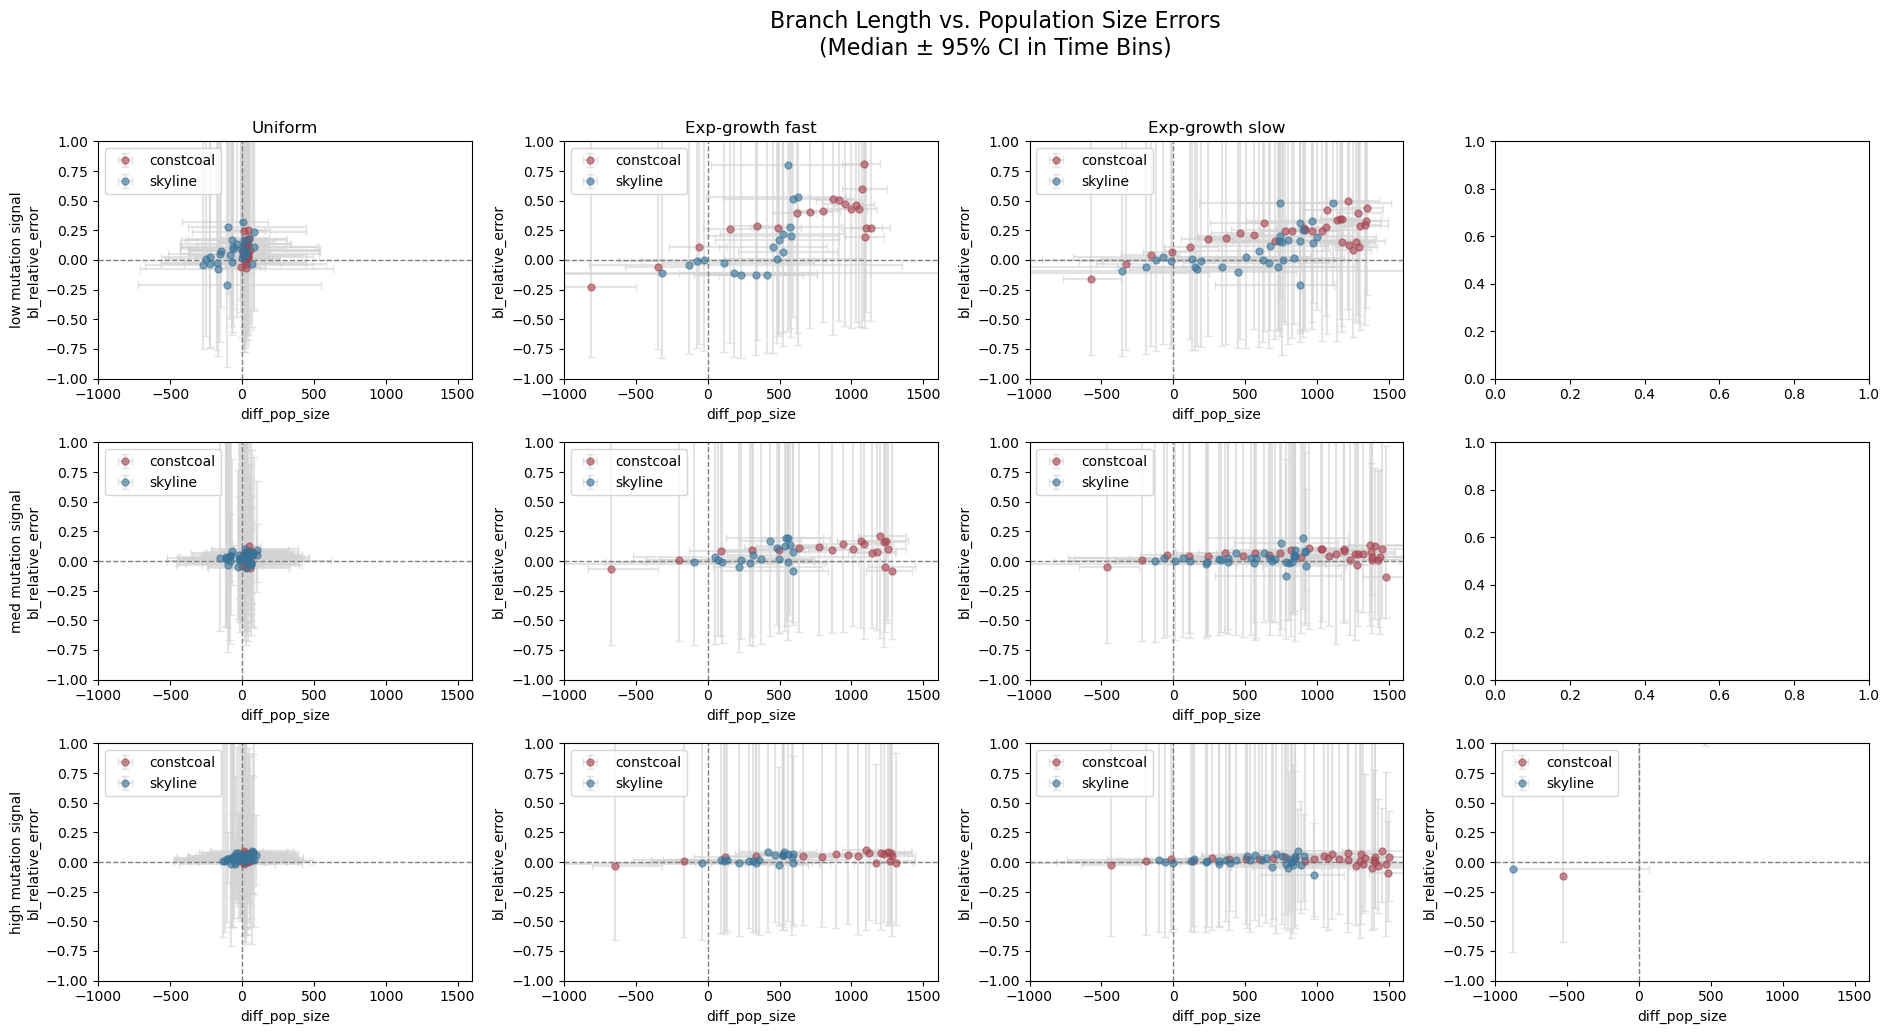

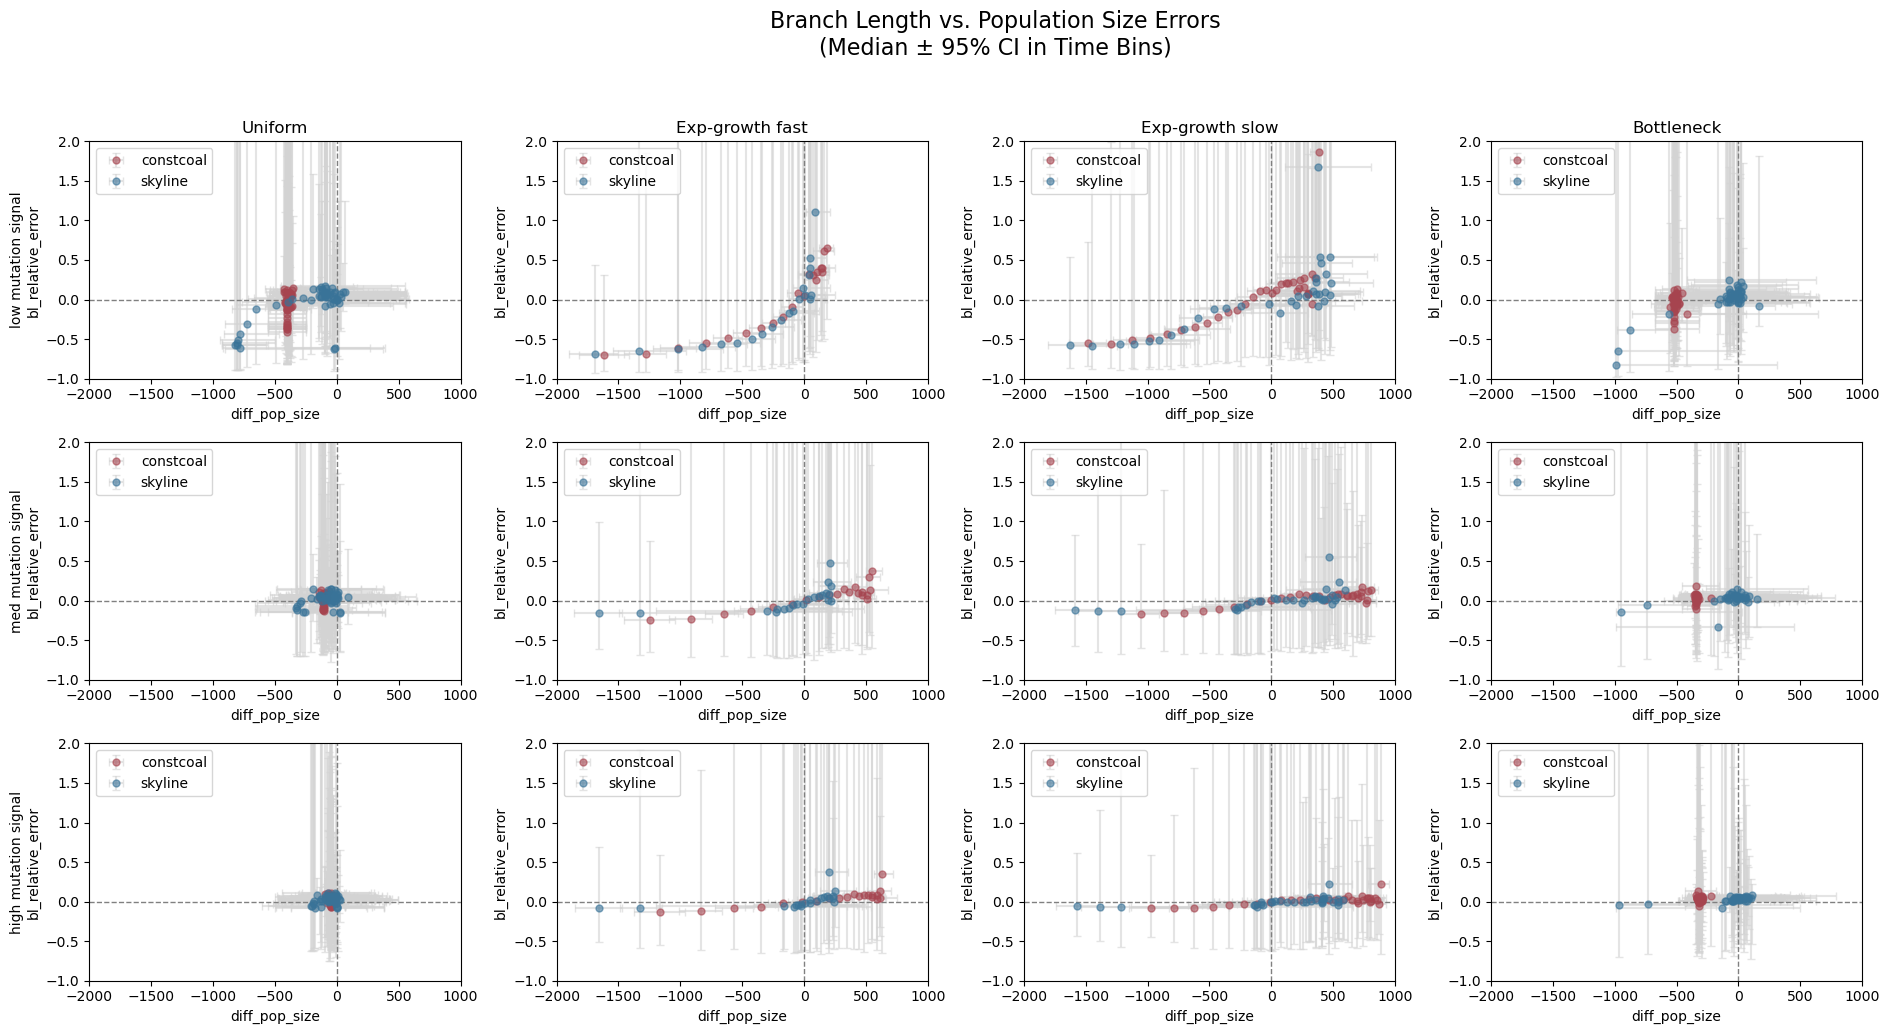

In [13]:
plot_bl_vs_popsize_error_by_time_bin(tree_metrics_combined, sampling = "independenthomochronous", bin_width = 10, pop_error_col='diff_pop_size', bl_error_col='bl_relative_error', x_range = (-1000, 1600), y_range = (-1,1), show_errorbars=True, min_values_per_bin = 10)
plot_bl_vs_popsize_error_by_time_bin(tree_metrics_combined, sampling = "linearconstant", bin_width = 10, pop_error_col='diff_pop_size', bl_error_col='bl_relative_error', x_range = (-2000, 1000), y_range = (-1,2), show_errorbars=True, min_values_per_bin = 10)